# Daily City-Level Weather Modeling

This notebook converts the raw irregular weather snapshot data into a daily city-level panel before any time-series modeling. The first modeling target is `temperature_celsius`; duplicate Fahrenheit fields and subjective `feels_like` fields are excluded from the primary target workflow.

## Workflow

1. Load the irregular observation dataset.
2. Convert each observation timestamp into a city-local calendar date.
3. Aggregate snapshots into one row per city per day.
4. Check coverage and missing days, especially for Bandar Seri Begawan.
5. Run first-pass time-series diagnostics on daily mean temperature.
6. Prepare lag and rolling features for a later XGBoost model.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

## Load Data

The raw file contains weather snapshots, not a clean daily series. Multiple observations may exist for the same city and day, and some days may be missing entirely.

In [3]:
DATA_PATH = "GlobalWeatherRepository.csv"

raw_df = pd.read_csv(DATA_PATH)

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]:,}")
display(raw_df.head())
display(pd.Series(raw_df.columns, name="columns"))

Rows: 135,658
Columns: 41


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


0                          country
1                    location_name
2                         latitude
3                        longitude
4                         timezone
5               last_updated_epoch
6                     last_updated
7              temperature_celsius
8           temperature_fahrenheit
9                   condition_text
10                        wind_mph
11                        wind_kph
12                     wind_degree
13                  wind_direction
14                     pressure_mb
15                     pressure_in
16                       precip_mm
17                       precip_in
18                        humidity
19                           cloud
20              feels_like_celsius
21           feels_like_fahrenheit
22                   visibility_km
23                visibility_miles
24                        uv_index
25                        gust_mph
26                        gust_kph
27     air_quality_Carbon_Monoxide
28               air

## Daily Aggregation Specification

This section locks the preprocessing rules before modeling. 
Our focus as a target is daily mean `temperature_celsius`. Most continuous supporting variables are also averaged. 
Text fields, sun/moon fields, Fahrenheit duplicates, imperial duplicates, and `feels_like` fields are left out of the first modeling pass.

In [4]:
TARGET_COL = "temperature_celsius"
CITY_COL = "location_name"
TIMEZONE_COL = "timezone"
LOCAL_DATE_COL = "local_date"
# I enumerated it to make it easier to reference

# These columns are averaged because they are continuous weather or air-quality
# measurements. The goal is to create one stable daily representation per city.
MEAN_AGG_COLS = [
    "temperature_celsius",
    "precip_mm",
    "humidity",
    "cloud",
    "pressure_mb",
    "wind_kph",
    "uv_index",
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_us-epa-index",
    "air_quality_gb-defra-index",
]

# Keep only columns that actually exist so this notebook is resilient if the
# dataset version changes slightly.
mean_agg_cols = [col for col in MEAN_AGG_COLS if col in raw_df.columns]

missing_expected_cols = sorted(set(MEAN_AGG_COLS) - set(mean_agg_cols))
if missing_expected_cols:
    print("Missing expected aggregation columns:", missing_expected_cols)

mean_agg_cols

['temperature_celsius',
 'precip_mm',
 'humidity',
 'cloud',
 'pressure_mb',
 'wind_kph',
 'uv_index',
 'air_quality_Carbon_Monoxide',
 'air_quality_Ozone',
 'air_quality_Nitrogen_dioxide',
 'air_quality_Sulphur_dioxide',
 'air_quality_PM2.5',
 'air_quality_PM10',
 'air_quality_us-epa-index',
 'air_quality_gb-defra-index']

## Build Daily City Panel

`last_updated` is treated as the local wall-clock timestamp for each row. We extract its calendar date directly so cities are not silently forced into one shared timezone. `last_updated_epoch` remains available for audit checks, but the daily grouping is based on the local calendar date.

In [5]:
df = raw_df.copy()

# Parse the local timestamp string. These timestamps are city-local snapshots,
# so the extracted date is the modeling date used for daily aggregation.
df["last_updated_local"] = pd.to_datetime(df["last_updated"], errors="coerce")

# Normalize to midnight to represent the calendar day of the observation.
df[LOCAL_DATE_COL] = df["last_updated_local"].dt.normalize() 

# Keep a UTC timestamp from the epoch for traceability. We do not group on this
# field because grouping on UTC dates would shift some local observations into
# a neighboring calendar day.
df["last_updated_utc"] = pd.to_datetime(df["last_updated_epoch"], unit="s", utc=True, errors="coerce")

# Convert numeric modeling columns after loading. Invalid strings become NaN,
# which lets aggregation and missingness checks expose data-quality issues.
for col in mean_agg_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# columns to group by for daily aggregation
group_cols = ["country", CITY_COL, TIMEZONE_COL, LOCAL_DATE_COL]

daily_panel = (
    df.groupby(group_cols, dropna=False)
    .agg(
        **{col: (col, "mean") for col in mean_agg_cols},
        raw_observations=(TARGET_COL, "size"),
        first_observation_local=("last_updated_local", "min"),
        last_observation_local=("last_updated_local", "max"),
    ) # aggregate by taking the mean of the continuous measurement columns, and also count the number of raw observations during the day and capture the first and last local timestamps for traceability
    .reset_index()
    .sort_values([CITY_COL, LOCAL_DATE_COL]) # sort by city and date for easier inspection of the time series patterns in each city
)

print(f"Daily panel rows: {daily_panel.shape[0]:,}")
display(daily_panel.head())

Daily panel rows: 135,408


,country,location_name,timezone,local_date,temperature_celsius,precip_mm,humidity,cloud,pressure_mb,wind_kph,uv_index,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,raw_observations,first_observation_local,last_observation_local
11116,Belgium,'S Gravenjansdijk,Europe/Brussels,2024-05-31,16.0,0.29,82.0,50.0,1014.0,28.1,4.0,186.9,87.3,2.7,1.3,2.2,3.4,1.0,1.0,1,2024-05-31 16:15:00,2024-05-31 16:15:00
11117,Belgium,'S Gravenjansdijk,Europe/Brussels,2024-06-01,16.0,0.01,88.0,100.0,1019.0,15.1,4.0,186.9,88.7,2.2,1.8,6.5,19.6,1.0,1.0,1,2024-06-01 16:30:00,2024-06-01 16:30:00
11118,Belgium,'S Gravenjansdijk,Europe/Brussels,2024-06-04,18.0,0.06,77.0,25.0,1011.0,25.9,4.0,185.3,83.0,5.1,2.2,5.7,6.0,1.0,1.0,1,2024-06-04 16:15:00,2024-06-04 16:15:00
11119,Belgium,'S Gravenjansdijk,Europe/Brussels,2024-06-05,15.0,0.00,44.0,25.0,1015.0,11.2,4.0,186.9,94.4,1.9,1.4,1.2,2.4,1.0,1.0,1,2024-06-05 16:15:00,2024-06-05 16:15:00
11120,Belgium,'S Gravenjansdijk,Europe/Brussels,2024-06-11,15.2,0.41,59.0,75.0,1017.0,24.1,3.0,178.6,82.3,1.4,0.9,0.5,0.9,1.0,1.0,1,2024-06-11 16:15:00,2024-06-11 16:15:00


## Coverage Diagnostics by City

A daily model needs enough continuity to be meaningful. This table checks how much daily coverage each city has after aggregation.

In [6]:
coverage = (
    daily_panel.groupby(["country", CITY_COL, TIMEZONE_COL], dropna=False)
    .agg(
        min_date=(LOCAL_DATE_COL, "min"),
        max_date=(LOCAL_DATE_COL, "max"),
        distinct_days=(LOCAL_DATE_COL, "nunique"),
        raw_observations=("raw_observations", "sum"),
        missing_target_days=(TARGET_COL, lambda values: values.isna().sum()),
    )
    .reset_index()
)

# Expected days describes the full daily span between the city's first and last
# observed date. Missing days are gaps inside that span, not dates before or
# after the dataset covers the city.
coverage["expected_days_in_range"] = (
    coverage["max_date"] - coverage["min_date"]
).dt.days + 1
coverage["missing_days_in_range"] = coverage["expected_days_in_range"] - coverage["distinct_days"]
coverage["avg_observations_per_observed_day"] = (
    coverage["raw_observations"] / coverage["distinct_days"]
)
coverage["coverage_ratio"] = coverage["distinct_days"] / coverage["expected_days_in_range"]

coverage = coverage.sort_values(
    ["coverage_ratio", "distinct_days", "raw_observations"],
    ascending=[False, False, False],
)

display(coverage.head(20))

,country,location_name,timezone,min_date,max_date,distinct_days,raw_observations,missing_target_days,expected_days_in_range,missing_days_in_range,avg_observations_per_observed_day,coverage_ratio
180,Palau,Airai,Pacific/Palau,2024-08-15,2025-08-20,371,371,0,371,0,1.000000,1.0
188,Paraguay,Aurora,America/Asuncion,2025-06-11,2025-08-20,71,71,0,71,0,1.000000,1.0
258,Ukraine,Kyiv,Europe/Kyiv,2026-02-10,2026-04-15,65,65,0,65,0,1.000000,1.0
33,Bulgaria,Lom,Europe/Bucharest,2024-05-16,2024-06-19,35,36,0,35,0,1.028571,1.0
99,Iceland,Grindavik,Atlantic/Reykjavik,2024-05-16,2024-06-19,35,36,0,35,0,1.028571,1.0
115,Jamaica,Norman Gardens,America/Jamaica,2024-05-16,2024-06-19,35,36,0,35,0,1.028571,1.0
147,Maldives,Felidhoo,Indian/Maldives,2024-05-16,2024-06-17,33,34,0,33,0,1.030303,1.0
179,Palau,Adkip,Pacific/Palau,2024-05-31,2024-06-19,20,20,0,20,0,1.000000,1.0
19,Belgium,'S Gravenstaffel,Europe/Brussels,2024-05-16,2024-05-30,15,16,0,15,0,1.066667,1.0
44,Cameroon,Yaounde,Africa/Douala,2024-05-16,2024-05-30,15,16,0,15,0,1.066667,1.0


## Bandar Seri Begawan Coverage

Before choosing SARIMA or XGBoost, validate whether Bandar Seri Begawan has enough daily continuity for time-series modeling.

In [7]:
SELECTED_CITY = "Bandar Seri Begawan"

bsb_daily = (
    daily_panel.loc[daily_panel[CITY_COL].eq(SELECTED_CITY)]
    .sort_values(LOCAL_DATE_COL)
    .copy()
)

if bsb_daily.empty:
    raise ValueError(f"No rows found for {SELECTED_CITY!r}. Check spelling in location_name.")

display(coverage.loc[coverage[CITY_COL].eq(SELECTED_CITY)])

full_bsb_index = pd.date_range(
    start=bsb_daily[LOCAL_DATE_COL].min(),
    end=bsb_daily[LOCAL_DATE_COL].max(),
    freq="D",
)

# Reindexing exposes calendar days with no observations after aggregation. This
# is the daily series that time-series diagnostics and models should inspect.
bsb_series = (
    bsb_daily.set_index(LOCAL_DATE_COL)
    .reindex(full_bsb_index)
    .rename_axis(LOCAL_DATE_COL)
)

missing_dates = bsb_series.index[bsb_series[TARGET_COL].isna()]

print(f"Date range: {full_bsb_index.min().date()} to {full_bsb_index.max().date()}")
print(f"Calendar days in range: {len(full_bsb_index):,}")
print(f"Missing target days: {bsb_series[TARGET_COL].isna().sum():,}")
display(pd.Series(missing_dates, name="missing_dates").head(30))

,country,location_name,timezone,min_date,max_date,distinct_days,raw_observations,missing_target_days,expected_days_in_range,missing_days_in_range,avg_observations_per_observed_day,coverage_ratio
31,Brunei Darussalam,Bandar Seri Begawan,Asia/Brunei,2024-05-16,2026-04-15,693,695,0,700,7,1.002886,0.99


Date range: 2024-05-16 to 2026-04-15
Calendar days in range: 700
Missing target days: 7


0   2024-05-17
1   2024-06-06
2   2024-07-21
3   2024-07-22
4   2026-01-19
5   2026-03-08
6   2026-03-09
Name: missing_dates, dtype: datetime64[us]

## Chronological Split and Train-Only Gap Repair

To minimize leakage, the full daily series is split by date before any target repair. Short missing target gaps are interpolated in the training period only. Test targets remain observed; missing test target days are excluded from later metrics instead of being imputed.

In [8]:
TRAIN_FRACTION = 0.80
# 80/20 split between training and test sets is a common heuristic in time-series forecasting to provide enough data 
# for model training while reserving a portion for evaluating out-of-sample performance. 

split_position = int(len(bsb_series) * TRAIN_FRACTION)
split_date = bsb_series.index[split_position]

bsb_train = bsb_series.loc[bsb_series.index < split_date].copy()
bsb_test = bsb_series.loc[bsb_series.index >= split_date].copy()

print(f"Split date: {split_date.date()}")
print(f"Train range: {bsb_train.index.min().date()} to {bsb_train.index.max().date()} ({len(bsb_train):,} days)")
print(f"Test range: {bsb_test.index.min().date()} to {bsb_test.index.max().date()} ({len(bsb_test):,} days)")
print(f"Missing train target days before repair: {bsb_train[TARGET_COL].isna().sum():,}")
print(f"Missing test target days left unimputed: {bsb_test[TARGET_COL].isna().sum():,}")

Split date: 2025-11-27
Train range: 2024-05-16 to 2025-11-26 (560 days)
Test range: 2025-11-27 to 2026-04-15 (140 days)
Missing train target days before repair: 4
Missing test target days left unimputed: 3


In [9]:
def interpolate_short_training_gaps(
    train_daily: pd.DataFrame,
    target_col: str,
    max_gap_days: int = 2,
) -> pd.DataFrame:
    """Interpolate short target gaps inside the training period only.

    The test period is intentionally excluded from this function so validation
    metrics are computed against observed targets. Restricting interpolation to
    short internal training gaps keeps the repair defensible when only a small
    number of daily targets are missing from a much larger series.
    """
    repaired = train_daily.copy()

    # Time interpolation uses the date index to bridge small internal gaps. The
    # limit prevents long missing runs from being smoothed into artificial data.
    repaired[target_col] = repaired[target_col].interpolate(
        method="time",
        limit=max_gap_days,
        limit_area="inside",
    )

    return repaired


bsb_train_repaired = interpolate_short_training_gaps(
    bsb_train,
    target_col=TARGET_COL,
    max_gap_days=2,
)

missing_train_before = bsb_train[TARGET_COL].isna().sum()
missing_train_after = bsb_train_repaired[TARGET_COL].isna().sum()
total_days = len(bsb_series)
missing_total = bsb_series[TARGET_COL].isna().sum()

print(f"Total missing target days: {missing_total:,} out of {total_days:,} daily rows")
print(f"Missing train target days before repair: {missing_train_before:,}")
print(f"Missing train target days after repair: {missing_train_after:,}")
print(f"Missing test target days still unimputed: {bsb_test[TARGET_COL].isna().sum():,}")

# This observed-only test table is the defensible target set for later metrics.
# Any missing test dates are omitted from scoring rather than estimated.
bsb_test_observed = bsb_test.dropna(subset=[TARGET_COL]).copy()
print(f"Observed test days available for metrics: {len(bsb_test_observed):,} of {len(bsb_test):,}")

Total missing target days: 7 out of 700 daily rows
Missing train target days before repair: 4
Missing train target days after repair: 0
Missing test target days still unimputed: 3
Observed test days available for metrics: 137 of 140


## Daily Temperature Diagnostics

These checks decide whether a classical time-series model is justified. They use the training period after short-gap repair so model assumptions are assessed without looking into the test window.

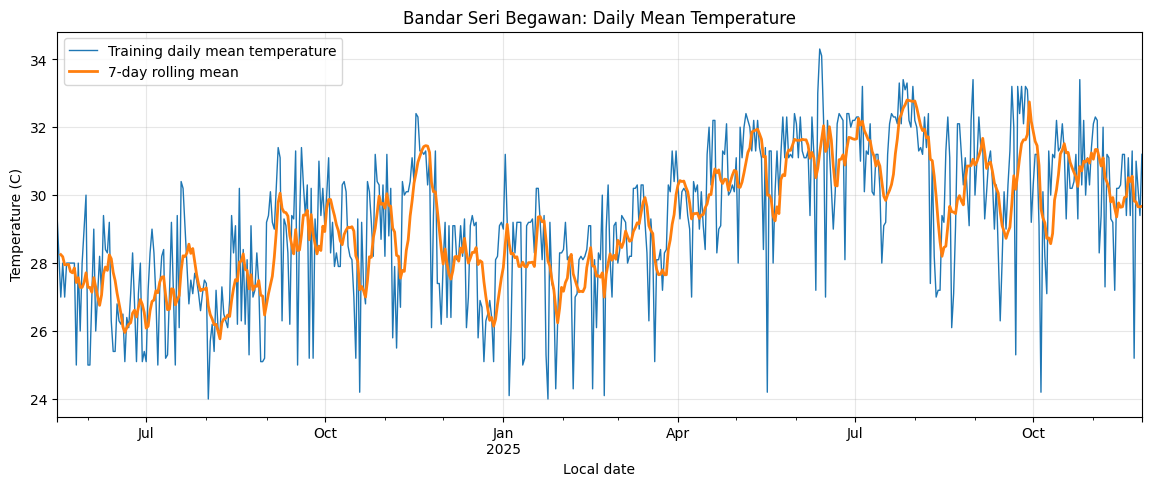

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

bsb_train_repaired[TARGET_COL].plot(ax=ax, label="Training daily mean temperature", linewidth=1)
bsb_train_repaired[TARGET_COL].rolling(7, min_periods=3).mean().plot(
    ax=ax,
    label="7-day rolling mean",
    linewidth=2,
)

ax.set_title(f"{SELECTED_CITY}: Daily Mean Temperature")
ax.set_xlabel("Local date")
ax.set_ylabel("Temperature (C)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

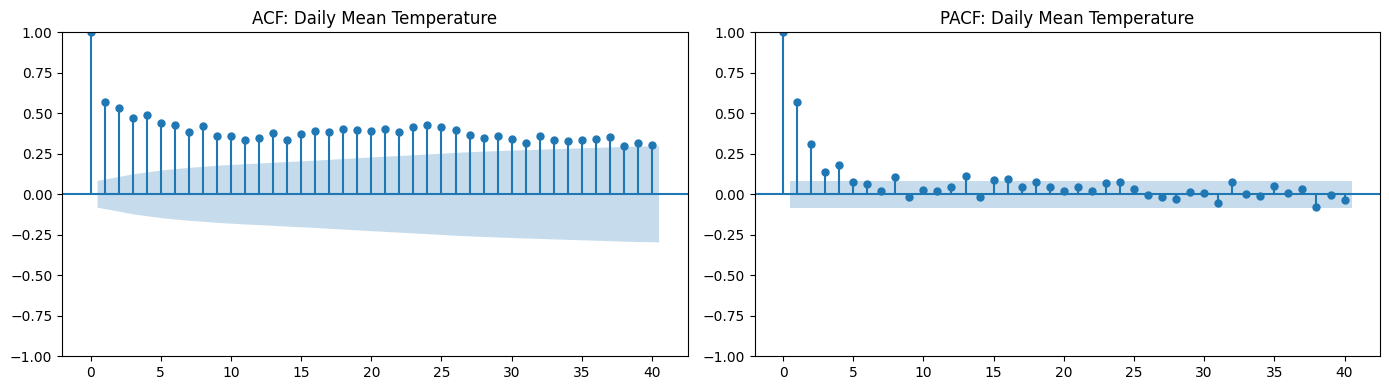

ADF stationarity test
ADF statistic: -2.2141
p-value: 0.2012
Used lags: 17
Observations: 542
Critical values:
  1%: -3.4425
  5%: -2.8669
  10%: -2.5696


In [11]:
diagnostic_series = bsb_train_repaired[TARGET_COL].dropna()


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diagnostic_series, lags=min(40, len(diagnostic_series) // 2), ax=axes[0])
plot_pacf(diagnostic_series, lags=min(40, len(diagnostic_series) // 2), ax=axes[1], method="ywm")
axes[0].set_title("ACF: Daily Mean Temperature")
axes[1].set_title("PACF: Daily Mean Temperature")
plt.tight_layout()
plt.show()

adf_stat, p_value, used_lags, n_obs, critical_values, _ = adfuller(diagnostic_series)
print("ADF stationarity test")
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Used lags: {used_lags}")
print(f"Observations: {n_obs}")
print("Critical values:")
for level, value in critical_values.items():
    print(f"  {level}: {value:.4f}")


ACF plot shows strong significant positive autocorrelation at many lags, indicating that daily mean temperature in Bandar Seri Begawan is not independent across time and exhibits clear serial dependence. 

The PACF plot shows a significant spike at lag 1, and slightly smaller spikes at lags 2-4, while subsequent lags shrink quickly towards zero. This means that the immediate previous day's temperature has a strong influence on the current day's temperature, while the influence of temperatures from two or more days ago is much weaker after accounting for the lag 1 effect.

The ADF test show that the p-value of 0.2012 is high, so we fail to reject the null hypothesis of non-stationarity, suggesting that the series may be non-stationary, especially at conventional significance levels of 0.05, 0.1, etc.

As a result, my initial hypothesis is that a period of 7 days (weekly seasonality) may be a significant component of the 
temperature patterns in Bandar Seri Begawan.

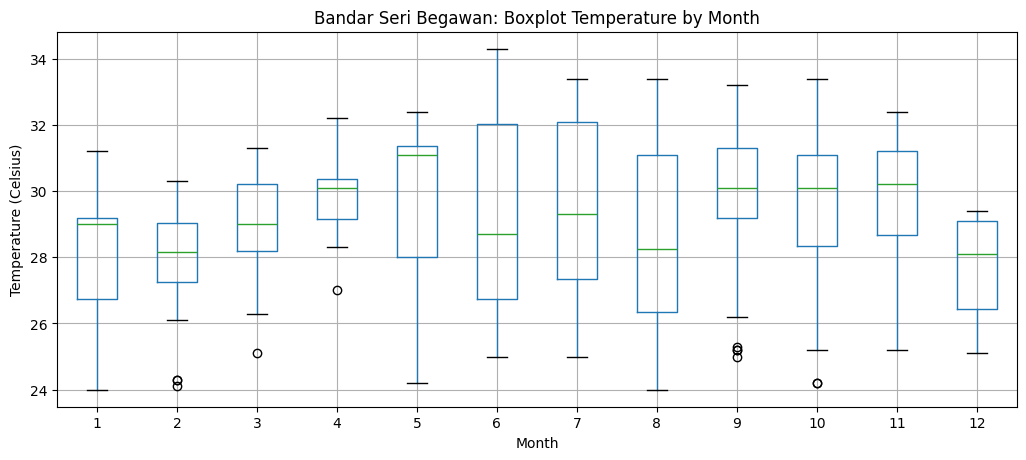

,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
1,31.0,27.980645,1.963232,24.0,26.750,29.00,29.200,31.2
2,28.0,27.875000,1.568822,24.1,27.250,28.15,29.025,30.3
3,31.0,28.951613,1.375953,25.1,28.200,29.00,30.200,31.3
4,30.0,30.073333,1.218233,27.0,29.150,30.10,30.375,32.2
5,47.0,29.888298,2.136973,24.2,28.000,31.10,31.350,32.4
6,60.0,29.050000,2.767640,25.0,26.725,28.70,32.025,34.3
7,62.0,29.524194,2.516555,25.0,27.350,29.30,32.100,33.4
8,62.0,28.583871,2.461387,24.0,26.350,28.25,31.100,33.4
9,60.0,29.883333,2.050396,25.0,29.175,30.10,31.300,33.2


In [12]:
month_diagnostics = bsb_train_repaired[[TARGET_COL]].dropna().copy()
month_diagnostics["month"] = month_diagnostics.index.month

fig, ax = plt.subplots(figsize=(12, 5))
month_diagnostics.boxplot(column=TARGET_COL, by="month", ax=ax)
ax.set_title(f"{SELECTED_CITY}: Boxplot Temperature by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Temperature (Celsius)")
plt.suptitle("")
plt.show()

display(month_diagnostics.groupby("month")[TARGET_COL].describe())

Because the missing target days are sparse, about 7 out of 700 daily rows, the defensible approach is to split chronologically first and only interpolate short target gaps inside the training period. The test period remains observed-only for evaluation, which minimizes leakage and keeps performance metrics honest.

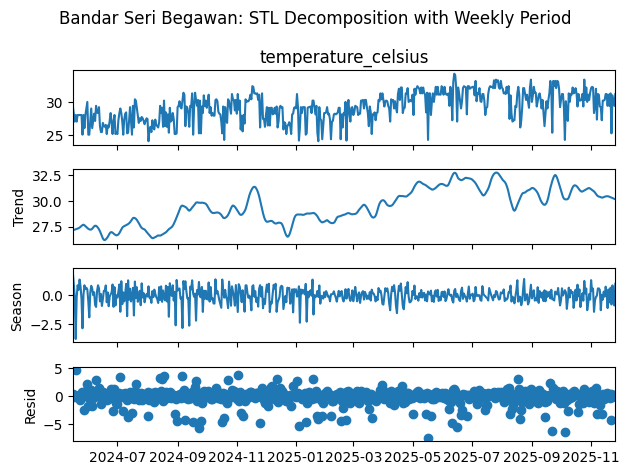

In [13]:
stl_input = bsb_train_repaired[TARGET_COL].dropna()

stl_result = STL(stl_input, period=7, robust=True).fit()
stl_result.plot()
plt.suptitle(f"{SELECTED_CITY}: STL Decomposition with Weekly Period")
plt.tight_layout()
plt.show()

There is only modest weekly seasonality, so this is more exploratory than conclusive. I also tried annual decomposition but given that there is only 2 annual cycles, it was not informative.

However, there is indeed a changing trend and still residual noise, so we will try ARIMA-family models still - specifically first-differencing. We will compare classical time-series modelling approaches against more ML-focused models.

## Secondary Precipitation Diagnostics

This is a complementary view rather than a new primary modeling target. Precipitation can be more intermittent and zero-heavy than temperature, so the goal here is simply to inspect whether daily `precip_mm` shows visible short-term structure in the training period.

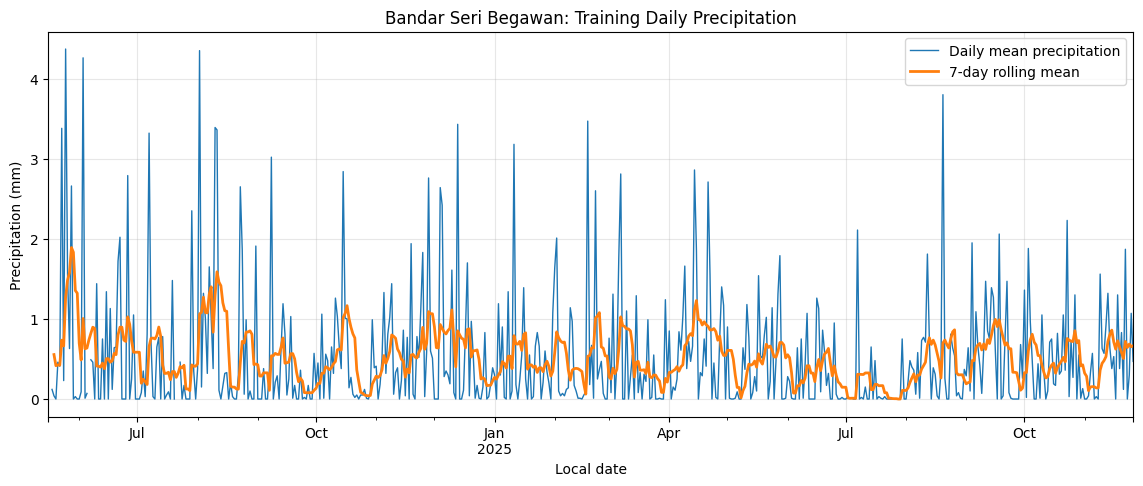

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

bsb_train_repaired["precip_mm"].plot(ax=ax, label="Daily mean precipitation", linewidth=1)
bsb_train_repaired["precip_mm"].rolling(7, min_periods=3).mean().plot(
    ax=ax,
    label="7-day rolling mean",
    linewidth=2,
)

ax.set_title(f"{SELECTED_CITY}: Training Daily Precipitation")
ax.set_xlabel("Local date")
ax.set_ylabel("Precipitation (mm)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

A month-wise boxplot is a light complementary check for whether rainfall intensity looks different across the calendar year without committing us to a full precipitation modeling branch.

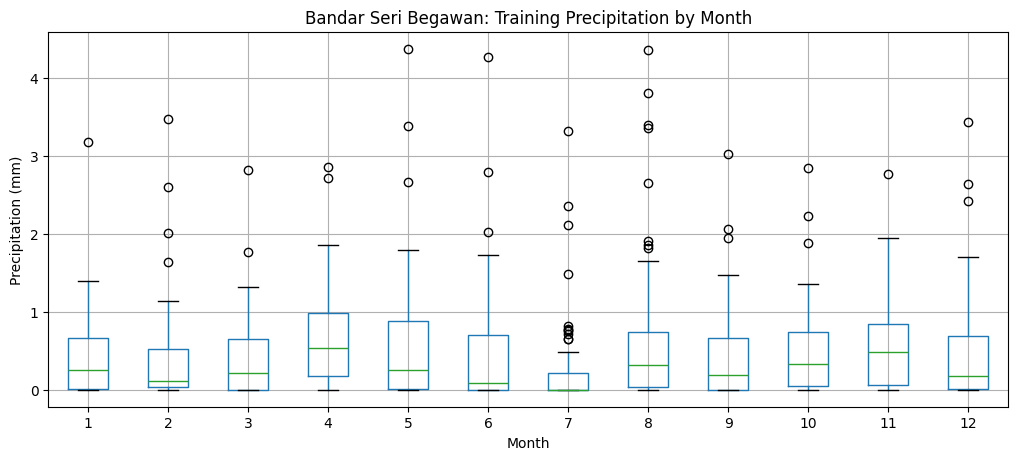

,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
1,31.0,0.487097,0.656913,0.0,0.0100,0.250,0.6600,3.18
2,28.0,0.528214,0.881228,0.0,0.0400,0.110,0.5200,3.47
3,31.0,0.463548,0.664663,0.0,0.0000,0.220,0.6550,2.81
4,30.0,0.743333,0.763180,0.0,0.1750,0.540,0.9850,2.86
5,46.0,0.634457,0.933007,0.0,0.0025,0.255,0.8750,4.37
6,59.0,0.477119,0.778595,0.0,0.0000,0.090,0.7000,4.26
7,60.0,0.279333,0.624844,0.0,0.0000,0.000,0.2150,3.32
8,62.0,0.658871,0.991431,0.0,0.0325,0.320,0.7375,4.35
9,60.0,0.451000,0.621512,0.0,0.0000,0.190,0.6650,3.02


In [15]:
precip_month_diagnostics = bsb_train_repaired[["precip_mm"]].dropna().copy()
precip_month_diagnostics["month"] = precip_month_diagnostics.index.month

fig, ax = plt.subplots(figsize=(12, 5))
precip_month_diagnostics.boxplot(column="precip_mm", by="month", ax=ax)
ax.set_title(f"{SELECTED_CITY}: Training Precipitation by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Precipitation (mm)")
plt.suptitle("")
plt.show()

display(precip_month_diagnostics.groupby("month")["precip_mm"].describe())

## First Difference for ARIMA d=1

The checks below difference the training target once, then rerun the plot, ADF test, ACF, and PACF without using the test window.

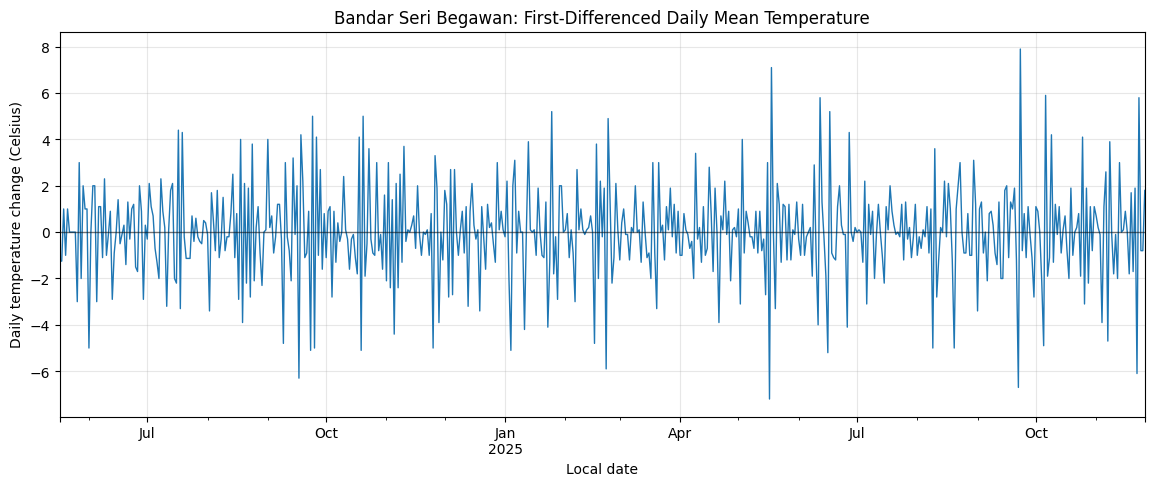

count    559.000000
mean       0.003041
std        2.046981
min       -7.200000
25%       -1.050000
50%        0.000000
75%        1.100000
max        7.900000
Name: temperature_celsius, dtype: float64

In [16]:
bsb_train_diff_1 = bsb_train_repaired[TARGET_COL].diff().dropna()

fig, ax = plt.subplots(figsize=(14, 5))
bsb_train_diff_1.plot(ax=ax, linewidth=1)

ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.set_title(f"{SELECTED_CITY}: First-Differenced Daily Mean Temperature")
ax.set_xlabel("Local date")
ax.set_ylabel("Daily temperature change (Celsius)")
ax.grid(True, alpha=0.3)
plt.show()

display(bsb_train_diff_1.describe())

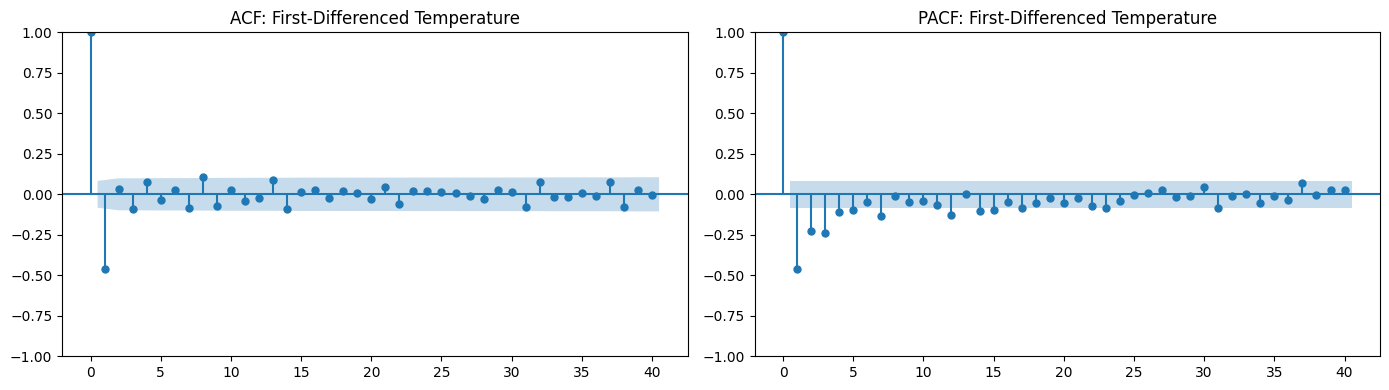

ADF stationarity test after first differencing
ADF statistic: -9.8270
p-value: 0.0000
Used lags: 16
Observations: 542
Critical values:
  1%: -3.4425
  5%: -2.8669
  10%: -2.5696


In [17]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
diff_lags = min(40, len(bsb_train_diff_1) // 2)
plot_acf(bsb_train_diff_1, lags=diff_lags, ax=axes[0])
plot_pacf(bsb_train_diff_1, lags=diff_lags, ax=axes[1], method="ywm")
axes[0].set_title("ACF: First-Differenced Temperature")
axes[1].set_title("PACF: First-Differenced Temperature")
plt.tight_layout()
plt.show()

diff_adf_stat, diff_p_value, diff_used_lags, diff_n_obs, diff_critical_values, _ = adfuller(
    bsb_train_diff_1
)
print("ADF stationarity test after first differencing")
print(f"ADF statistic: {diff_adf_stat:.4f}")
print(f"p-value: {diff_p_value:.4f}")
print(f"Used lags: {diff_used_lags}")
print(f"Observations: {diff_n_obs}")
print("Critical values:")
for level, value in diff_critical_values.items():
    print(f"  {level}: {value:.4f}")


Given that the ADF test results in a p-value of essentially zero, we can reject non-stationarity. This means that `d` = 1.
The ACF plot still shows a strong negative spike at lag 1 while the rest are essentially zero. The PACF plot shows that negative lags at the beginning shrink to zero very quickly. This means that a low-order moving average or autoregressive moving average model is suitable.

My initial hypothesis was that we could have seasonality since by nature temperature should be seasonal. However, there is no strong evidence of seasonal structure through spikes at 7, 14, 21, etc.

Overall, this means we should try:

`ARIMA(0,1,1)`
`ARIMA(1,1,0)`
`ARIMA(1,1,1)` as potential models.

We will also try XGBoost as a more traditional ML model.

## Normalization and Scaling

Normalization is not applied in this workflow. 

For ARIMA-family models, scaling is generally not required because the model is built on the temporal structure of the target series in its original units, and keeping temperature in Celsius makes fitted values, residuals, and forecast errors easier to interpret. 

For tree-based models such as XGBoost, scaling is also generally not required because tree splits depend on feature ordering and threshold rules rather than distance-based geometry. Scaling would matter more for models such as regularized linear regression, k-nearest neighbors, or support vector machines. I discussed feature importance and selection when conducting XGBoost modelling below.

## Multivariate Exploratory Analysis

Before modeling, it is useful to inspect how the daily target relates to other aggregated weather features. The views below use training data only so the exploratory analysis stays aligned with the forecasting split.

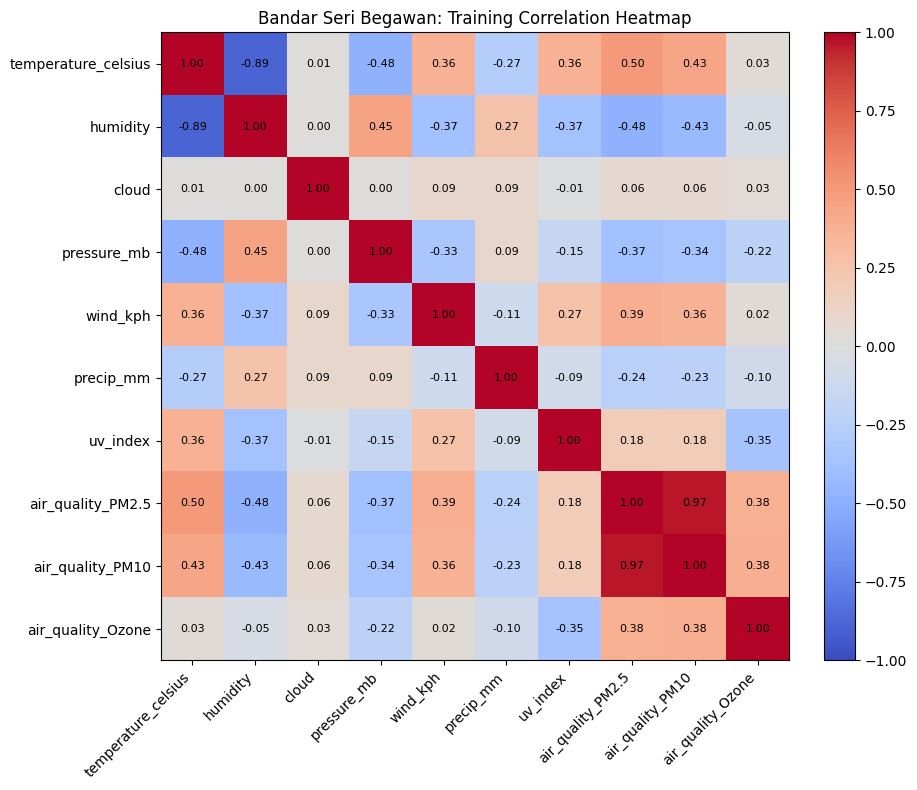

In [18]:
multivariate_feature_candidates = [
    TARGET_COL,
    "humidity",
    "cloud",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "uv_index",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Ozone",
]
multivariate_feature_candidates = [
    col for col in multivariate_feature_candidates if col in bsb_train_repaired.columns
]

training_multivariate_frame = bsb_train_repaired[multivariate_feature_candidates].copy()
training_correlation_matrix = training_multivariate_frame.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(training_correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(training_correlation_matrix.columns)))
ax.set_yticks(range(len(training_correlation_matrix.index)))
ax.set_xticklabels(training_correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(training_correlation_matrix.index)
ax.set_title(f"{SELECTED_CITY}: Training Correlation Heatmap")

for row_index in range(len(training_correlation_matrix.index)):
    for col_index in range(len(training_correlation_matrix.columns)):
        ax.text(
            col_index,
            row_index,
            f"{training_correlation_matrix.iloc[row_index, col_index]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8,
        )

plt.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [19]:
target_correlation_review = (
    training_correlation_matrix[[TARGET_COL]]
    .rename(columns={TARGET_COL: "correlation_with_temperature_celsius"})
    .drop(index=TARGET_COL, errors="ignore")
    .assign(absolute_correlation=lambda frame: frame["correlation_with_temperature_celsius"].abs())
    .sort_values("absolute_correlation", ascending=False)
)

display(target_correlation_review)

,correlation_with_temperature_celsius,absolute_correlation
humidity,-0.886041,0.886041
air_quality_PM2.5,0.497118,0.497118
pressure_mb,-0.478965,0.478965
air_quality_PM10,0.431042,0.431042
uv_index,0.361860,0.361860
wind_kph,0.360432,0.360432
precip_mm,-0.272511,0.272511
air_quality_Ozone,0.026741,0.026741
cloud,0.007316,0.007316


## XGBoost-Ready Training Feature Tables

These tables support several leakage-safe XGBoost variants. The baseline uses target lags, target rolling summaries, and calendar features only. Additional variants add lagged and rolling exogenous weather features built only from prior days. Same-day weather variables are excluded because they would not be known when forecasting the target day. Feature selection is performed later using training data only.

In [20]:
def add_time_series_features(city_daily: pd.DataFrame, target_col: str) -> pd.DataFrame:
    """Create simple supervised-learning features from a daily city series.

    The input must already be one row per calendar day for one city. Lagged and
    rolling features are shifted so each row only uses information that would
    have been available before the target day.
    """
    features = city_daily.copy().sort_index()

    # Calendar features let tree models learn recurring within-year patterns
    # without requiring a strict SARIMA-style seasonal structure.
    features["month"] = features.index.month
    features["day_of_year"] = features.index.dayofyear

    # Lag features expose short-memory temperature behavior to the model. Each
    # shift looks backward from the prediction date, preventing target leakage.
    for lag in [1, 3, 7]:
        features[f"{target_col}_lag_{lag}"] = features[target_col].shift(lag)

    # Rolling means summarize recent weather regimes. The shift ensures the
    # current day's target is not included in its own predictor values.
    for window in [3, 7]:
        features[f"{target_col}_rolling_mean_{window}"] = (
            features[target_col].shift(1).rolling(window=window, min_periods=window).mean()
        )

    return features


def add_lagged_exogenous_features(
    features: pd.DataFrame,
    exogenous_daily: pd.DataFrame,
    exogenous_cols: list[str],
    lags: list[int],
    rolling_windows: list[int],
) -> pd.DataFrame:
    """Add leakage-safe lagged and rolling exogenous features.

    Exogenous values are forward-filled chronologically before shifting. This
    means a missing weather snapshot can inherit only the most recent prior
    observation, never a future value.
    """
    enriched_features = features.copy()
    exogenous_filled = exogenous_daily[exogenous_cols].ffill()

    for col in exogenous_cols:
        # Lagged exogenous features describe prior weather states that would be
        # known before predicting the current target day.
        for lag in lags:
            enriched_features[f"{col}_lag_{lag}"] = exogenous_filled[col].shift(lag)

        # Rolling exogenous features summarize recent prior weather regimes.
        # The shift prevents same-day weather from entering the feature value.
        for window in rolling_windows:
            enriched_features[f"{col}_rolling_mean_{window}"] = (
                exogenous_filled[col].shift(1).rolling(window=window, min_periods=window).mean()
            )

    return enriched_features


def describe_xgboost_feature(feature_name: str) -> dict:
    """Label each engineered feature so importance and selection stay readable."""
    if feature_name in {"month", "day_of_year"}:
        return {
            "feature": feature_name,
            "feature_group": "calendar",
            "base_variable": feature_name,
            "transform": "calendar",
            "lookback": pd.NA,
        }

    if "_rolling_mean_" in feature_name:
        base_variable, lookback = feature_name.rsplit("_rolling_mean_", 1)
        transform = "rolling_mean"
    elif "_lag_" in feature_name:
        base_variable, lookback = feature_name.rsplit("_lag_", 1)
        transform = "lag"
    else:
        base_variable = feature_name
        lookback = pd.NA
        transform = "raw"

    feature_group = "target history" if base_variable == TARGET_COL else "exogenous history"
    return {
        "feature": feature_name,
        "feature_group": feature_group,
        "base_variable": base_variable,
        "transform": transform,
        "lookback": pd.NA if lookback is pd.NA else int(lookback),
    }


# Build supervised features from the repaired training period only. Test-period
# target lag features will be created recursively later, using prior predictions
# rather than actual test targets.
bsb_train_features = add_time_series_features(bsb_train_repaired, TARGET_COL)

xgboost_feature_cols = [
    "month",
    "day_of_year",
    f"{TARGET_COL}_lag_1",
    f"{TARGET_COL}_lag_3",
    f"{TARGET_COL}_lag_7",
    f"{TARGET_COL}_rolling_mean_3",
    f"{TARGET_COL}_rolling_mean_7",
]


# Lagged exogenous features test whether prior weather states add signal beyond
# target history. They are shifted or rolled from prior days only.
lagged_exogenous_cols = [
    "humidity",
    "pressure_mb",
    "cloud",
    "wind_kph",
    "precip_mm",
    "uv_index",
]
lagged_exogenous_cols = [col for col in lagged_exogenous_cols if col in bsb_train_repaired.columns]
EXOGENOUS_LAGS = [1, 3, 7]
EXOGENOUS_ROLLING_WINDOWS = [3, 7]

bsb_train_features_all = add_lagged_exogenous_features(
    features=bsb_train_features,
    exogenous_daily=bsb_train_repaired,
    exogenous_cols=lagged_exogenous_cols,
    lags=EXOGENOUS_LAGS,
    rolling_windows=EXOGENOUS_ROLLING_WINDOWS,
)

exogenous_lag_1_feature_cols = [f"{col}_lag_1" for col in lagged_exogenous_cols]
exogenous_lag_1_3_feature_cols = [
    f"{col}_lag_{lag}"
    for col in lagged_exogenous_cols
    for lag in [1, 3]
]
exogenous_lag_1_3_7_feature_cols = [
    f"{col}_lag_{lag}"
    for col in lagged_exogenous_cols
    for lag in [1, 3, 7]
]
exogenous_rolling_3_feature_cols = [f"{col}_rolling_mean_3" for col in lagged_exogenous_cols]
exogenous_rolling_all_feature_cols = [
    f"{col}_rolling_mean_{window}"
    for col in lagged_exogenous_cols
    for window in EXOGENOUS_ROLLING_WINDOWS
]

xgboost_feature_configs = {
    "XGBoost recursive": xgboost_feature_cols,
    "XGBoost exog lag1": xgboost_feature_cols + exogenous_lag_1_feature_cols,
    "XGBoost exog lag1+lag3": xgboost_feature_cols + exogenous_lag_1_3_feature_cols,
    "XGBoost exog lag1+lag3+lag7": xgboost_feature_cols + exogenous_lag_1_3_7_feature_cols,
    "XGBoost exog lag1+lag3+lag7+roll3": (
        xgboost_feature_cols + exogenous_lag_1_3_7_feature_cols + exogenous_rolling_3_feature_cols
    ),
    "XGBoost exog full": (
        xgboost_feature_cols + exogenous_lag_1_3_7_feature_cols + exogenous_rolling_all_feature_cols
    ),
}

train_model_tables = {
    model_name: bsb_train_features_all[[TARGET_COL] + feature_cols].dropna().copy()
    for model_name, feature_cols in xgboost_feature_configs.items()
}

# Backward-compatible aliases for the simplest XGBoost variants.
train_model_table = train_model_tables["XGBoost recursive"]
xgboost_exog_feature_cols = xgboost_feature_configs["XGBoost exog lag1"]
train_model_table_exog = train_model_tables["XGBoost exog lag1"]

xgboost_training_summary = pd.DataFrame(
    [
        {
            "model": model_name,
            "n_features": len(feature_cols),
            "train_rows": len(train_model_tables[model_name]),
        }
        for model_name, feature_cols in xgboost_feature_configs.items()
    ]
)

xgboost_candidate_features = sorted(
    {feature for feature_cols in xgboost_feature_configs.values() for feature in feature_cols}
)
xgboost_feature_catalog = pd.DataFrame(
    [describe_xgboost_feature(feature) for feature in xgboost_candidate_features]
)
xgboost_feature_catalog["used_in_models"] = xgboost_feature_catalog["feature"].map(
    lambda feature: ", ".join(
        model_name for model_name, feature_cols in xgboost_feature_configs.items() if feature in feature_cols
    )
)
xgboost_feature_catalog["n_models_using_feature"] = xgboost_feature_catalog["used_in_models"].map(
    lambda model_names: len(model_names.split(", ")) if model_names else 0
)
xgboost_feature_catalog = xgboost_feature_catalog.sort_values(
    ["feature_group", "base_variable", "transform", "lookback", "feature"]
).reset_index(drop=True)

xgboost_feature_family_summary = (
    xgboost_feature_catalog.groupby(["feature_group", "transform"], dropna=False)
    .agg(
        n_features=("feature", "count"),
        variables=("base_variable", lambda values: ", ".join(sorted(pd.unique(values)))),
    )
    .reset_index()
)

display(xgboost_feature_family_summary)
display(xgboost_training_summary)
display(xgboost_feature_catalog)
display(train_model_table.head())
display(train_model_tables["XGBoost exog full"].head())



,feature_group,transform,n_features,variables
0,calendar,calendar,2,"day_of_year, month"
1,exogenous history,lag,18,"cloud, humidity, precip_mm, pressure_mb, uv_in..."
2,exogenous history,rolling_mean,12,"cloud, humidity, precip_mm, pressure_mb, uv_in..."
3,target history,lag,3,temperature_celsius
4,target history,rolling_mean,2,temperature_celsius


,model,n_features,train_rows
0,XGBoost recursive,7,553
1,XGBoost exog lag1,13,553
2,XGBoost exog lag1+lag3,19,553
3,XGBoost exog lag1+lag3+lag7,25,553
4,XGBoost exog lag1+lag3+lag7+roll3,31,553
5,XGBoost exog full,37,553


,feature,feature_group,base_variable,transform,lookback,used_in_models,n_models_using_feature
0,day_of_year,calendar,day_of_year,calendar,<NA>,"XGBoost recursive, XGBoost exog lag1, XGBoost ...",6
1,month,calendar,month,calendar,<NA>,"XGBoost recursive, XGBoost exog lag1, XGBoost ...",6
2,cloud_lag_1,exogenous history,cloud,lag,1,"XGBoost exog lag1, XGBoost exog lag1+lag3, XGB...",5
3,cloud_lag_3,exogenous history,cloud,lag,3,"XGBoost exog lag1+lag3, XGBoost exog lag1+lag3...",4
4,cloud_lag_7,exogenous history,cloud,lag,7,"XGBoost exog lag1+lag3+lag7, XGBoost exog lag1...",3
5,cloud_rolling_mean_3,exogenous history,cloud,rolling_mean,3,"XGBoost exog lag1+lag3+lag7+roll3, XGBoost exo...",2
6,cloud_rolling_mean_7,exogenous history,cloud,rolling_mean,7,XGBoost exog full,1
7,humidity_lag_1,exogenous history,humidity,lag,1,"XGBoost exog lag1, XGBoost exog lag1+lag3, XGB...",5
8,humidity_lag_3,exogenous history,humidity,lag,3,"XGBoost exog lag1+lag3, XGBoost exog lag1+lag3...",4
9,humidity_lag_7,exogenous history,humidity,lag,7,"XGBoost exog lag1+lag3+lag7, XGBoost exog lag1...",3


,temperature_celsius,month,day_of_year,temperature_celsius_lag_1,temperature_celsius_lag_3,temperature_celsius_lag_7,temperature_celsius_rolling_mean_3,temperature_celsius_rolling_mean_7
local_date,,,,,,,,
2024-05-23,28.0,5,144,28.0,27.0,29.50,27.666667,27.964286
2024-05-24,28.0,5,145,28.0,28.0,28.25,28.000000,27.750000
2024-05-25,28.0,5,146,28.0,28.0,27.00,28.000000,27.714286
2024-05-26,25.0,5,147,28.0,28.0,28.00,28.000000,27.857143
2024-05-27,28.0,5,148,25.0,28.0,27.00,27.000000,27.428571


,temperature_celsius,month,day_of_year,temperature_celsius_lag_1,temperature_celsius_lag_3,temperature_celsius_lag_7,temperature_celsius_rolling_mean_3,temperature_celsius_rolling_mean_7,humidity_lag_1,humidity_lag_3,humidity_lag_7,pressure_mb_lag_1,pressure_mb_lag_3,pressure_mb_lag_7,cloud_lag_1,cloud_lag_3,cloud_lag_7,wind_kph_lag_1,wind_kph_lag_3,wind_kph_lag_7,precip_mm_lag_1,precip_mm_lag_3,precip_mm_lag_7,uv_index_lag_1,uv_index_lag_3,uv_index_lag_7,humidity_rolling_mean_3,humidity_rolling_mean_7,pressure_mb_rolling_mean_3,pressure_mb_rolling_mean_7,cloud_rolling_mean_3,cloud_rolling_mean_7,wind_kph_rolling_mean_3,wind_kph_rolling_mean_7,precip_mm_rolling_mean_3,precip_mm_rolling_mean_7,uv_index_rolling_mean_3,uv_index_rolling_mean_7
local_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-05-23,28.0,5,144,28.0,27.0,29.50,27.666667,27.964286,100.0,94.0,92.0,1009.0,1008.0,1008.0,75.0,25.0,75.0,3.6,3.6,11.2,0.41,0.00,1.505,1.0,1.0,4.5,94.333333,93.285714,1008.666667,1008.285714,41.666667,50.000000,3.600000,6.157143,0.290000,0.577143,1.0,2.0
2024-05-24,28.0,5,145,28.0,28.0,28.25,28.000000,27.750000,94.0,89.0,92.0,1008.0,1009.0,1008.0,50.0,25.0,75.0,3.6,3.6,11.2,3.38,0.46,1.505,1.0,1.0,4.5,94.333333,93.571429,1008.666667,1008.285714,50.000000,46.428571,3.600000,5.071429,1.416667,0.845000,1.0,1.5
2024-05-25,28.0,5,146,28.0,28.0,27.00,28.000000,27.714286,89.0,100.0,97.0,1009.0,1009.0,1009.0,25.0,75.0,50.0,3.6,3.6,6.3,0.23,0.41,0.120,1.0,1.0,1.0,94.333333,93.142857,1008.666667,1008.428571,50.000000,39.285714,3.600000,3.985714,1.340000,0.662857,1.0,1.0
2024-05-26,25.0,5,147,28.0,28.0,28.00,28.000000,27.857143,100.0,94.0,89.0,1010.0,1008.0,1007.0,75.0,50.0,25.0,4.0,3.6,3.6,4.37,3.38,0.040,1.0,1.0,1.0,94.333333,93.571429,1009.000000,1008.571429,50.000000,42.857143,3.733333,3.657143,2.660000,1.270000,1.0,1.0
2024-05-27,28.0,5,148,25.0,28.0,27.00,27.000000,27.428571,100.0,89.0,94.0,1011.0,1009.0,1008.0,75.0,25.0,25.0,6.1,3.6,3.6,1.56,0.23,0.000,1.0,1.0,1.0,96.333333,95.142857,1010.000000,1009.142857,58.333333,50.000000,4.566667,4.014286,2.053333,1.487143,1.0,1.0


## Moving Average Baseline

A recursive 7-day moving average is a simple sanity-check baseline. It forecasts each test day as the average of the latest seven target-history values, then appends that prediction to history before forecasting the next day. This keeps the baseline leakage-safe and lets errors propagate forward.

In [21]:
def calculate_mae(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Calculate mean absolute error in the target's original units."""
    return float(np.mean(np.abs(y_true - y_pred)))


def calculate_rmse(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Calculate root mean squared error to emphasize larger misses."""
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


MOVING_AVERAGE_WINDOW = 7
moving_average_predictions = []
moving_average_history = bsb_train_repaired[TARGET_COL].dropna().copy()

for forecast_date in bsb_test.index:
    # Use only training values and prior predictions. Actual test targets are
    # not added to history, so this is a true recursive holdout baseline.
    prediction = moving_average_history.iloc[-MOVING_AVERAGE_WINDOW:].mean()
    moving_average_predictions.append((forecast_date, prediction))
    moving_average_history.loc[forecast_date] = prediction

moving_average_forecast = pd.Series(
    data=[prediction for _, prediction in moving_average_predictions],
    index=[forecast_date for forecast_date, _ in moving_average_predictions],
    name=f"{MOVING_AVERAGE_WINDOW}-day moving average",
)

moving_average_test_target = bsb_test[TARGET_COL].dropna()
moving_average_forecast_observed = moving_average_forecast.loc[moving_average_test_target.index]

moving_average_results_df = pd.DataFrame(
    [
        {
            "model": f"{MOVING_AVERAGE_WINDOW}-day moving average",
            "model_type": "Recursive baseline",
            "mae": calculate_mae(moving_average_test_target, moving_average_forecast_observed),
            "rmse": calculate_rmse(moving_average_test_target, moving_average_forecast_observed),
            "aic": np.nan,
            "bic": np.nan,
        }
    ]
)

display(moving_average_results_df)

,model,model_type,mae,rmse,aic,bic
0,7-day moving average,Recursive baseline,1.239592,1.619948,NaN,NaN


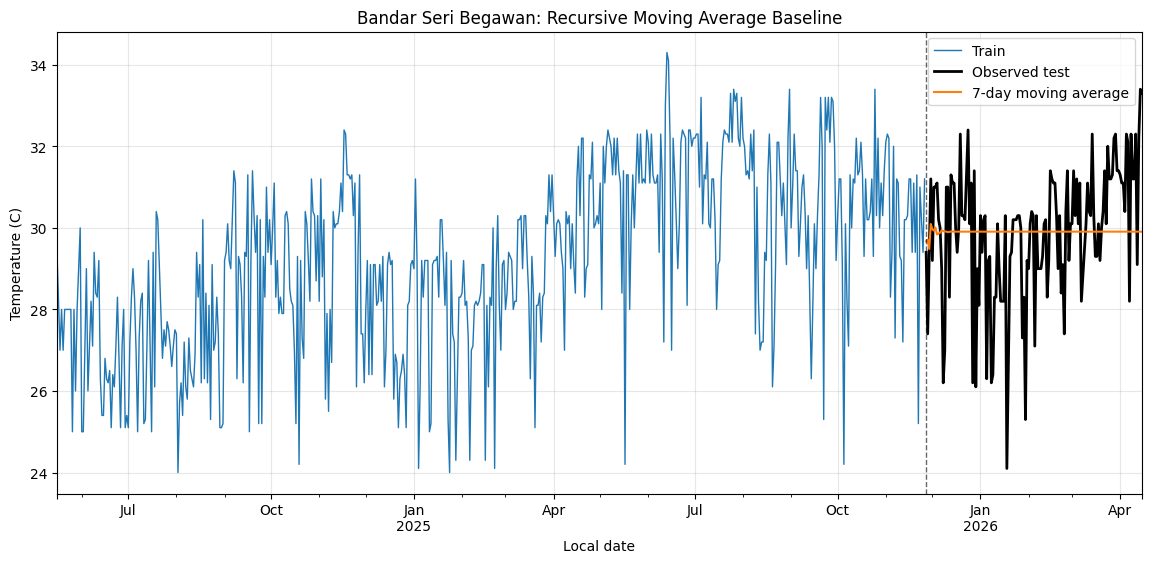

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))

bsb_train_repaired[TARGET_COL].plot(ax=ax, label="Train", linewidth=1)
bsb_test[TARGET_COL].dropna().plot(ax=ax, label="Observed test", linewidth=2, color="black")
moving_average_forecast.plot(ax=ax, label=f"{MOVING_AVERAGE_WINDOW}-day moving average", linewidth=1.5)

ax.axvline(split_date, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.set_title(f"{SELECTED_CITY}: Recursive Moving Average Baseline")
ax.set_xlabel("Local date")
ax.set_ylabel("Temperature (C)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## ARIMA Candidate Models

Based on the first-difference diagnostics, we compare `ARIMA(0,1,1)`, `ARIMA(1,1,0)`, and `ARIMA(1,1,1)`. 

MAE is the primary test metric because it is reported in Celsius and is easy to defend. 

RMSE is secondary because it highlights larger misses. 

AIC and BIC are useful for comparing ARIMA candidates in-sample, but test MAE should lead the practical decision.

In [23]:
arima_orders = [(0, 1, 1), (1, 1, 0), (1, 1, 1)]
arima_results = []
arima_forecasts = {}

# The ARIMA training series must be continuous after train-only interpolation.
# This check prevents accidentally fitting a classical model on hidden gaps.
arima_train_target = bsb_train_repaired[TARGET_COL].asfreq("D")
if arima_train_target.isna().any():
    raise ValueError(
        "The ARIMA training target still has missing values after short-gap repair. "
        "Review the remaining gaps before fitting ARIMA."
    )

arima_test_target = bsb_test[TARGET_COL].dropna()

    

for order in arima_orders:
    # Each candidate is fit on the training window only. Forecasts are then
    # aligned to observed test target days before calculating metrics.
    model = ARIMA(
        arima_train_target,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted_model = model.fit()

    forecast = fitted_model.forecast(steps=len(bsb_test))
    forecast = pd.Series(forecast.to_numpy(), index=bsb_test.index, name=f"ARIMA{order}")
    observed_forecast = forecast.loc[arima_test_target.index]

    arima_forecasts[f"ARIMA{order}"] = forecast
    arima_results.append(
        {
            "model": f"ARIMA{order}",
            "model_type": "ARIMA",
            "mae": calculate_mae(arima_test_target, observed_forecast),
            "rmse": calculate_rmse(arima_test_target, observed_forecast),
            "aic": fitted_model.aic,
            "bic": fitted_model.bic,
        }
    )

arima_results_df = pd.DataFrame(arima_results).sort_values("mae")
display(arima_results_df)


,model,model_type,mae,rmse,aic,bic
2,"ARIMA(1, 1, 1)",ARIMA,1.205654,1.637954,2153.899295,2166.866990
0,"ARIMA(0, 1, 1)",ARIMA,1.218489,1.626706,2165.550161,2174.195291
1,"ARIMA(1, 1, 0)",ARIMA,1.312714,1.772746,2254.613697,2263.262415


Based on these results, we are inclined to pick `ARIMA(1,1,1)` since the MAE is the lowest across the 3. RMSE is quite low, AIC is also quite low, and BIC is also relatively low.

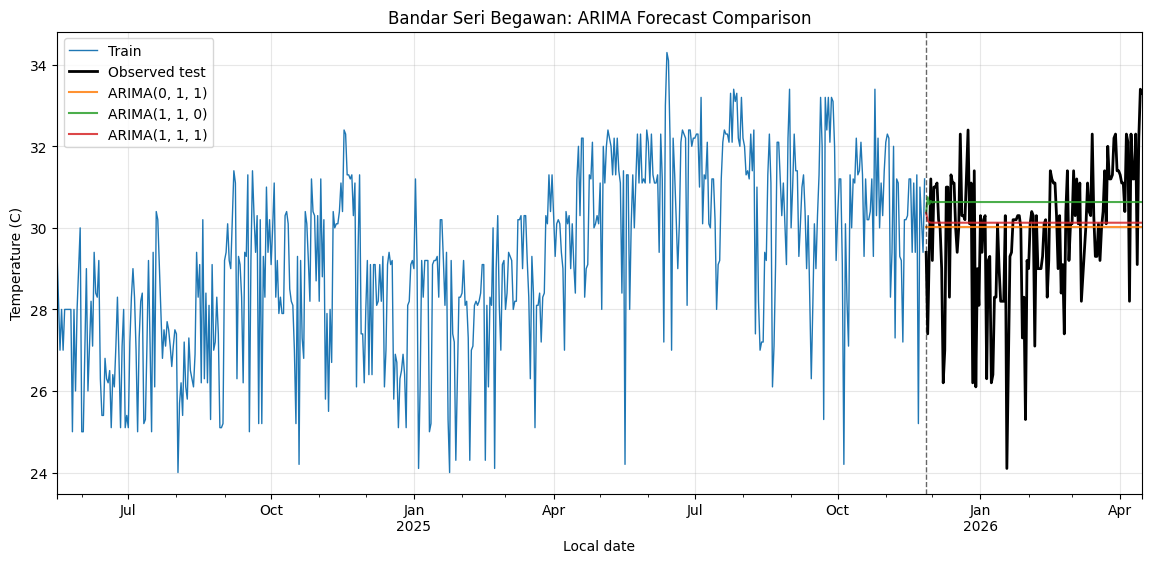

In [24]:
if arima_forecasts:
    fig, ax = plt.subplots(figsize=(14, 6))

    bsb_train_repaired[TARGET_COL].plot(ax=ax, label="Train", linewidth=1)
    bsb_test[TARGET_COL].dropna().plot(ax=ax, label="Observed test", linewidth=2, color="black")

    for model_name, forecast in arima_forecasts.items():
        forecast.plot(ax=ax, label=model_name, linewidth=1.5, alpha=0.85)

    ax.axvline(split_date, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(f"{SELECTED_CITY}: ARIMA Forecast Comparison")
    ax.set_xlabel("Local date")
    ax.set_ylabel("Temperature (C)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

 However, based on the forecasted plot across all 3 models, it's important to note that all ARIMA models struggled to capture the full variability in the test set, as evidenced by the relatively high error metrics. This suggests that while ARIMA can model some of the temporal structure, there may be additional factors or nonlinear patterns in the data that ARIMA alone cannot capture effectively.

## XGBoost Recursive Models

These XGBoost models are recursive over the test window: each predicted test value is appended to target history and used to build future target lag features. Actual test targets are never used as model inputs. The exogenous variants assume prior-day weather observations are available as the forecast window rolls forward; they still do not use same-day weather values for the target date.

Feature selection is made explicit in two steps:
1. Fit the richest exogenous XGBoost model on the training window only.
2. Rank that model's features by training-only gain importance, then refit a smaller model using the top-ranked features only.

The selection rule is descriptive rather than heavily tuned: it shows whether a compact feature subset can retain most of the signal from the full candidate pool.



In [ ]:
def build_recursive_xgboost_features(
    target_history: pd.Series,
    forecast_date: pd.Timestamp,
    feature_cols: list[str],
    exogenous_history: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Build one leakage-safe feature row for a recursive XGBoost forecast.

    During the test period, target_history contains repaired training targets
    plus previous XGBoost predictions. It never receives actual test targets,
    which prevents target leakage and allows forecast errors to propagate.
    """
    feature_values = {
        "month": forecast_date.month,
        "day_of_year": forecast_date.dayofyear,
        f"{TARGET_COL}_lag_1": target_history.iloc[-1],
        f"{TARGET_COL}_lag_3": target_history.iloc[-3],
        f"{TARGET_COL}_lag_7": target_history.iloc[-7],
        f"{TARGET_COL}_rolling_mean_3": target_history.iloc[-3:].mean(),
        f"{TARGET_COL}_rolling_mean_7": target_history.iloc[-7:].mean(),
    }

    if exogenous_history is not None:
        # Exogenous features are built from dates before the forecast date. This
        # includes lag and rolling windows, but never same-day weather values.
        prior_exogenous = exogenous_history.loc[: forecast_date - pd.Timedelta(days=1)]
        for col in lagged_exogenous_cols:
            for lag in EXOGENOUS_LAGS:
                feature_values[f"{col}_lag_{lag}"] = prior_exogenous[col].iloc[-lag]

            for window in EXOGENOUS_ROLLING_WINDOWS:
                feature_values[f"{col}_rolling_mean_{window}"] = prior_exogenous[col].iloc[-window:].mean()

    return pd.DataFrame([feature_values], index=[forecast_date])[feature_cols]


def forecast_xgboost_recursively(
    model,
    forecast_dates: pd.DatetimeIndex,
    feature_cols: list[str],
    exogenous_history: pd.DataFrame | None = None,
) -> pd.Series:
    """Forecast a test window recursively without using actual test targets."""
    recursive_predictions = []
    target_history = bsb_train_repaired[TARGET_COL].dropna().copy()

    for forecast_date in forecast_dates:
        # Build test features from training targets and previous predictions
        # only. Actual test targets are intentionally not added to history.
        feature_row = build_recursive_xgboost_features(
            target_history=target_history,
            forecast_date=forecast_date,
            feature_cols=feature_cols,
            exogenous_history=exogenous_history,
        )
        prediction = float(model.predict(xgb.DMatrix(feature_row))[0])

        recursive_predictions.append((forecast_date, prediction))
        target_history.loc[forecast_date] = prediction

    return pd.Series(
        data=[prediction for _, prediction in recursive_predictions],
        index=[forecast_date for forecast_date, _ in recursive_predictions],
    )


xgboost_results = []
xgboost_forecasts = {}
xgboost_forecast = pd.Series(dtype="float64")
xgboost_exog_forecast = pd.Series(dtype="float64")
xgboost_feature_importance = pd.DataFrame()
xgboost_selected_feature_summary = pd.DataFrame()
xgboost_feature_selection_summary = pd.DataFrame()

try:
    import xgboost as xgb

    xgb_params = {
        "objective": "reg:squarederror",
        "learning_rate": 0.03,
        "max_depth": 3,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "seed": 24,
    }
    NUM_BOOST_ROUND = 300

    # Exogenous history is forward-filled chronologically, so missing weather
    # snapshots use the most recent known prior values rather than future data.
    exogenous_history = pd.concat(
        [bsb_train_repaired[lagged_exogenous_cols], bsb_test[lagged_exogenous_cols]]
    ).sort_index().ffill()
    y_test_observed = bsb_test[TARGET_COL].dropna()

    trained_xgboost_models = {}
    for model_name, feature_cols in xgboost_feature_configs.items():
        train_table = train_model_tables[model_name]
        x_train = train_table[feature_cols]
        y_train = train_table[TARGET_COL]

        # Native DMatrix training avoids XGBoost's sklearn wrapper, which
        # requires scikit-learn. This keeps the baseline focused on XGBoost.
        model = xgb.train(
            params=xgb_params,
            dtrain=xgb.DMatrix(x_train, label=y_train),
            num_boost_round=NUM_BOOST_ROUND,
        )
        forecast = forecast_xgboost_recursively(
            model=model,
            forecast_dates=bsb_test.index,
            feature_cols=feature_cols,
            exogenous_history=exogenous_history,
        )
        forecast.name = model_name

        trained_xgboost_models[model_name] = model
        xgboost_forecasts[model_name] = forecast
        forecast_observed = forecast.loc[y_test_observed.index]

        xgboost_results.append(
            {
                "model": model_name,
                "model_type": "Gradient boosted trees",
                "mae": calculate_mae(y_test_observed, forecast_observed),
                "rmse": calculate_rmse(y_test_observed, forecast_observed),
                "aic": np.nan,
                "bic": np.nan,
                "n_features": len(feature_cols),
            }
        )

    # Feature selection uses training-only importance from the richest exogenous
    # model. Test performance is not used to rank or choose features.
    richest_model_name = "XGBoost exog full"
    richest_model = trained_xgboost_models[richest_model_name]
    gain_importance = richest_model.get_score(importance_type="gain")
    weight_importance = richest_model.get_score(importance_type="weight")
    cover_importance = richest_model.get_score(importance_type="cover")

    richest_model_feature_cols = xgboost_feature_configs[richest_model_name]
    xgboost_feature_importance = pd.DataFrame(
        [
            {
                **describe_xgboost_feature(feature),
                "gain": float(gain_importance.get(feature, 0.0)),
                "split_count": int(weight_importance.get(feature, 0)),
                "cover": float(cover_importance.get(feature, float("nan"))),
            }
            for feature in richest_model_feature_cols
        ]
    ).sort_values(["gain", "split_count"], ascending=[False, False]).reset_index(drop=True)

    total_gain = xgboost_feature_importance["gain"].sum()
    if total_gain > 0:
        xgboost_feature_importance["gain_share_pct"] = 100 * xgboost_feature_importance["gain"] / total_gain
    else:
        xgboost_feature_importance["gain_share_pct"] = 0.0

    xgboost_feature_importance["selection_rank"] = np.arange(1, len(xgboost_feature_importance) + 1)
    xgboost_feature_importance["cumulative_gain_share_pct"] = xgboost_feature_importance[
        "gain_share_pct"
    ].cumsum()

    TOP_K_FEATURES = 10
    selected_feature_cols = xgboost_feature_importance.head(TOP_K_FEATURES)["feature"].tolist()
    xgboost_feature_importance["selected_top_k"] = xgboost_feature_importance["feature"].isin(
        selected_feature_cols
    )
    xgboost_selected_feature_summary = xgboost_feature_importance.loc[
        xgboost_feature_importance["selected_top_k"],
        [
            "selection_rank",
            "feature",
            "feature_group",
            "base_variable",
            "transform",
            "lookback",
            "gain",
            "gain_share_pct",
            "cumulative_gain_share_pct",
            "split_count",
        ],
    ].reset_index(drop=True)
    xgboost_feature_selection_summary = pd.DataFrame(
        [
            {
                "selection_model": richest_model_name,
                "candidate_features": len(richest_model_feature_cols),
                "selected_features": TOP_K_FEATURES,
                "selection_rule": f"Top {TOP_K_FEATURES} features by training gain importance",
                "cumulative_gain_captured_pct": xgboost_selected_feature_summary[
                    "gain_share_pct"
                ].sum(),
            }
        ]
    )

    selected_train_table = bsb_train_features_all[[TARGET_COL] + selected_feature_cols].dropna().copy()
    selected_model = xgb.train(
        params=xgb_params,
        dtrain=xgb.DMatrix(selected_train_table[selected_feature_cols], label=selected_train_table[TARGET_COL]),
        num_boost_round=NUM_BOOST_ROUND,
    )
    selected_forecast = forecast_xgboost_recursively(
        model=selected_model,
        forecast_dates=bsb_test.index,
        feature_cols=selected_feature_cols,
        exogenous_history=exogenous_history,
    )
    selected_model_name = f"XGBoost selected top {TOP_K_FEATURES}"
    selected_forecast.name = selected_model_name
    xgboost_forecasts[selected_model_name] = selected_forecast
    selected_forecast_observed = selected_forecast.loc[y_test_observed.index]
    xgboost_results.append(
        {
            "model": selected_model_name,
            "model_type": "Gradient boosted trees",
            "mae": calculate_mae(y_test_observed, selected_forecast_observed),
            "rmse": calculate_rmse(y_test_observed, selected_forecast_observed),
            "aic": np.nan,
            "bic": np.nan,
            "n_features": len(selected_feature_cols),
        }
    )

    # Simple mean ensembles let us test whether averaging across recursive
    # XGBoost variants reduces model-specific forecast error on the same test
    # window.
    xgboost_forecast_frame = pd.DataFrame(xgboost_forecasts).sort_index()

    ensemble_all_name = "XGBoost ensemble (all variants)"
    ensemble_all_forecast = xgboost_forecast_frame.mean(axis=1)
    ensemble_all_forecast.name = ensemble_all_name
    xgboost_forecasts[ensemble_all_name] = ensemble_all_forecast
    ensemble_all_observed = ensemble_all_forecast.loc[y_test_observed.index]
    xgboost_results.append(
        {
            "model": ensemble_all_name,
            "model_type": "Gradient boosted trees ensemble",
            "mae": calculate_mae(y_test_observed, ensemble_all_observed),
            "rmse": calculate_rmse(y_test_observed, ensemble_all_observed),
            "aic": np.nan,
            "bic": np.nan,
            "n_features": np.nan,
        }
    )

    xgboost_results_df = pd.DataFrame(xgboost_results).sort_values("mae").reset_index(drop=True)
    top_3_member_names = (
        xgboost_results_df.loc[
            xgboost_results_df["model"].isin(xgboost_forecast_frame.columns), "model"
        ]
        .head(3)
        .tolist()
    )

    ensemble_top_3_name = "XGBoost ensemble (top 3)"
    ensemble_top_3_forecast = xgboost_forecast_frame[top_3_member_names].mean(axis=1)
    ensemble_top_3_forecast.name = ensemble_top_3_name
    xgboost_forecasts[ensemble_top_3_name] = ensemble_top_3_forecast
    ensemble_top_3_observed = ensemble_top_3_forecast.loc[y_test_observed.index]
    xgboost_results.append(
        {
            "model": ensemble_top_3_name,
            "model_type": "Gradient boosted trees ensemble",
            "mae": calculate_mae(y_test_observed, ensemble_top_3_observed),
            "rmse": calculate_rmse(y_test_observed, ensemble_top_3_observed),
            "aic": np.nan,
            "bic": np.nan,
            "n_features": np.nan,
        }
    )

    xgboost_forecast = xgboost_forecasts["XGBoost recursive"]
    xgboost_exog_forecast = xgboost_forecasts["XGBoost exog lag1"]
    xgboost_results_df = pd.DataFrame(xgboost_results).sort_values("mae").reset_index(drop=True)
    display(xgboost_results_df)
except Exception as exc:
    xgboost_results_df = pd.DataFrame()
    print("Skipping XGBoost because it could not run in this environment.")
    print(f"XGBoost error: {exc}")



,model,model_type,mae,rmse,aic,bic,n_features
0,XGBoost exog lag1+lag3+lag7+roll3,Gradient boosted trees,1.680241,2.045387,NaN,NaN,31.0
1,XGBoost ensemble (top 3),Gradient boosted trees ensemble,1.775431,2.176961,NaN,NaN,NaN
2,XGBoost exog lag1+lag3+lag7,Gradient boosted trees,1.866478,2.210963,NaN,NaN,25.0
3,XGBoost selected top 10,Gradient boosted trees,1.870604,2.385653,NaN,NaN,10.0
4,XGBoost exog full,Gradient boosted trees,1.912093,2.287499,NaN,NaN,37.0
5,XGBoost ensemble (all variants),Gradient boosted trees ensemble,1.966241,2.331499,NaN,NaN,NaN
6,XGBoost exog lag1+lag3,Gradient boosted trees,1.989261,2.368894,NaN,NaN,19.0
7,XGBoost exog lag1,Gradient boosted trees,2.080148,2.499093,NaN,NaN,13.0
8,XGBoost recursive,Gradient boosted trees,2.785429,3.092839,NaN,NaN,7.0


## XGBoost Feature Importance and Selection

This section makes the selection rule visible instead of burying it in code. 
The table shows how the richest exogenous XGBoost model ranked its training-only features, and the chart shows how much cumulative gain is captured as features are added from most to least important.



,selection_model,candidate_features,selected_features,selection_rule,cumulative_gain_captured_pct
0,XGBoost exog full,37,10,Top 10 features by training gain importance,59.431005


,selection_rank,feature,feature_group,base_variable,transform,lookback,gain,gain_share_pct,cumulative_gain_share_pct,split_count
0,1,uv_index_rolling_mean_3,exogenous history,uv_index,rolling_mean,3,84.026810,15.431645,15.431645,66
1,2,temperature_celsius_rolling_mean_3,target history,temperature_celsius,rolling_mean,3,67.644447,12.423000,27.854645,83
2,3,humidity_rolling_mean_7,exogenous history,humidity,rolling_mean,7,44.648418,8.199746,36.054391,42
3,4,temperature_celsius_rolling_mean_7,target history,temperature_celsius,rolling_mean,7,26.396353,4.847728,40.902119,71
4,5,humidity_rolling_mean_3,exogenous history,humidity,rolling_mean,3,21.797541,4.003150,44.905269,83
5,6,uv_index_lag_1,exogenous history,uv_index,lag,1,19.905722,3.655714,48.560983,49
6,7,wind_kph_rolling_mean_7,exogenous history,wind_kph,rolling_mean,7,17.051338,3.131503,51.692486,107
7,8,uv_index_rolling_mean_7,exogenous history,uv_index,rolling_mean,7,15.655931,2.875234,54.567720,50
8,9,temperature_celsius_lag_1,target history,temperature_celsius,lag,1,14.707316,2.701020,57.268740,106
9,10,precip_mm_lag_1,exogenous history,precip_mm,lag,1,11.773744,2.162265,59.431005,79


,feature,feature_group,base_variable,transform,lookback,gain,split_count,cover,gain_share_pct,selection_rank,cumulative_gain_share_pct,selected_top_k
0,uv_index_rolling_mean_3,exogenous history,uv_index,rolling_mean,3,84.026810,66,274.575745,15.431645,1,15.431645,True
1,temperature_celsius_rolling_mean_3,target history,temperature_celsius,rolling_mean,3,67.644447,83,234.831329,12.423000,2,27.854645,True
2,humidity_rolling_mean_7,exogenous history,humidity,rolling_mean,7,44.648418,42,179.476196,8.199746,3,36.054391,True
3,temperature_celsius_rolling_mean_7,target history,temperature_celsius,rolling_mean,7,26.396353,71,134.661972,4.847728,4,40.902119,True
4,humidity_rolling_mean_3,exogenous history,humidity,rolling_mean,3,21.797541,83,254.144577,4.003150,5,44.905269,True
5,uv_index_lag_1,exogenous history,uv_index,lag,1,19.905722,49,263.673462,3.655714,6,48.560983,True
6,wind_kph_rolling_mean_7,exogenous history,wind_kph,rolling_mean,7,17.051338,107,245.149536,3.131503,7,51.692486,True
7,uv_index_rolling_mean_7,exogenous history,uv_index,rolling_mean,7,15.655931,50,243.720001,2.875234,8,54.567720,True
8,temperature_celsius_lag_1,target history,temperature_celsius,lag,1,14.707316,106,170.226410,2.701020,9,57.268740,True
9,precip_mm_lag_1,exogenous history,precip_mm,lag,1,11.773744,79,230.531647,2.162265,10,59.431005,True


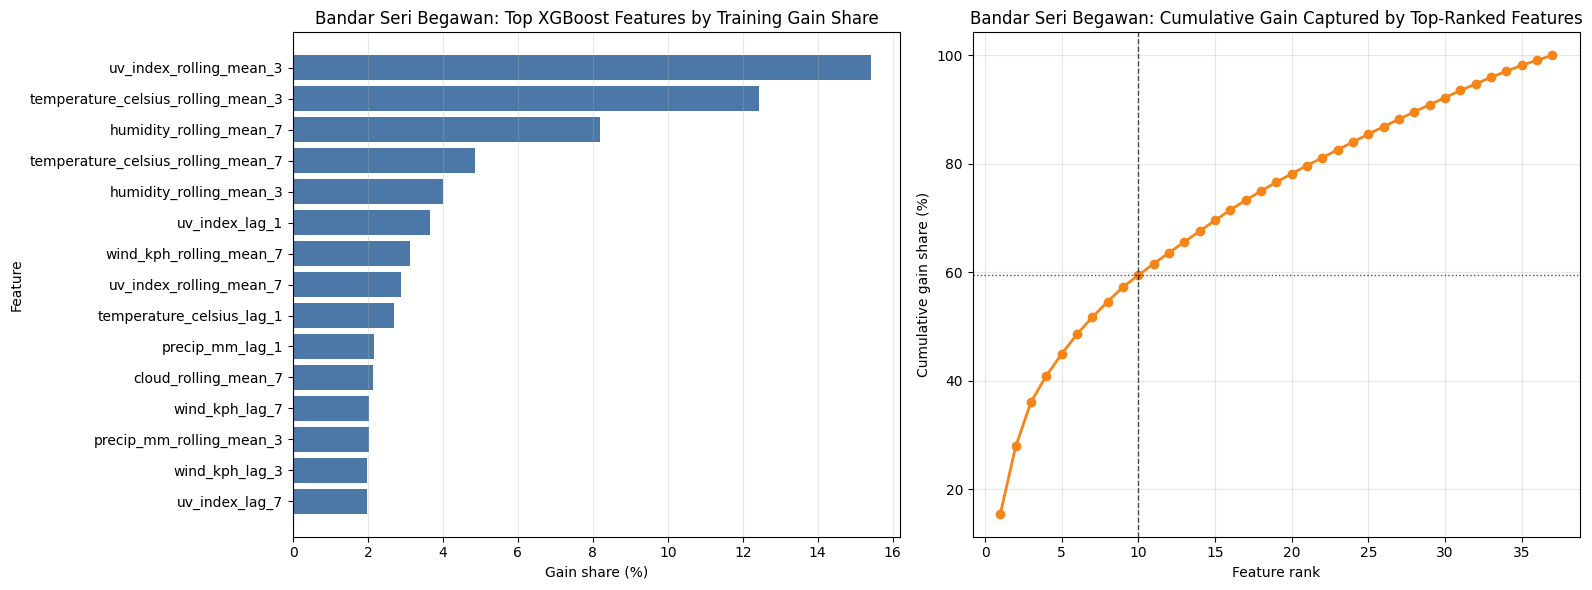

In [26]:
if not xgboost_feature_importance.empty:
    display(xgboost_feature_selection_summary)
    display(xgboost_selected_feature_summary)
    display(xgboost_feature_importance)

    top_features_to_plot = xgboost_feature_importance.head(15).iloc[::-1]
    cumulative_gain_at_top_k = float(xgboost_selected_feature_summary["gain_share_pct"].sum())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].barh(top_features_to_plot["feature"], top_features_to_plot["gain_share_pct"], color="#4C78A8")
    axes[0].set_title(f"{SELECTED_CITY}: Top XGBoost Features by Training Gain Share")
    axes[0].set_xlabel("Gain share (%)")
    axes[0].set_ylabel("Feature")
    axes[0].grid(True, axis="x", alpha=0.3)

    axes[1].plot(
        xgboost_feature_importance["selection_rank"],
        xgboost_feature_importance["cumulative_gain_share_pct"],
        marker="o",
        linewidth=2,
        color="#F58518",
    )
    axes[1].axvline(TOP_K_FEATURES, color="black", linestyle="--", linewidth=1, alpha=0.7)
    axes[1].axhline(cumulative_gain_at_top_k, color="black", linestyle=":", linewidth=1, alpha=0.7)
    axes[1].set_title(f"{SELECTED_CITY}: Cumulative Gain Captured by Top-Ranked Features")
    axes[1].set_xlabel("Feature rank")
    axes[1].set_ylabel("Cumulative gain share (%)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("XGBoost feature importance is unavailable because XGBoost results are empty.")



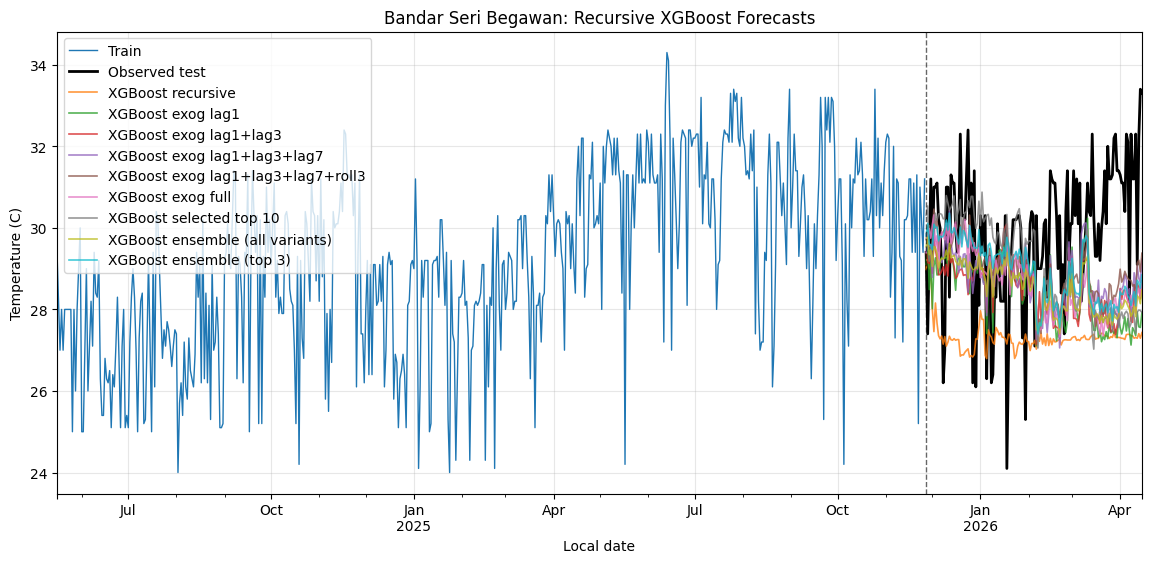

In [27]:
if xgboost_forecasts:
    fig, ax = plt.subplots(figsize=(14, 6))

    bsb_train_repaired[TARGET_COL].plot(ax=ax, label="Train", linewidth=1)
    bsb_test[TARGET_COL].dropna().plot(ax=ax, label="Observed test", linewidth=2, color="black")

    for model_name, forecast in xgboost_forecasts.items():
        forecast.plot(ax=ax, label=model_name, linewidth=1.2, alpha=0.8)

    ax.axvline(split_date, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(f"{SELECTED_CITY}: Recursive XGBoost Forecasts")
    ax.set_xlabel("Local date")
    ax.set_ylabel("Temperature (C)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

## Top 3 Recursive XGBoost Forecasts

The full XGBoost plot can get crowded once several feature variants are tested. This view keeps only the three XGBoost variants with the lowest test MAE.

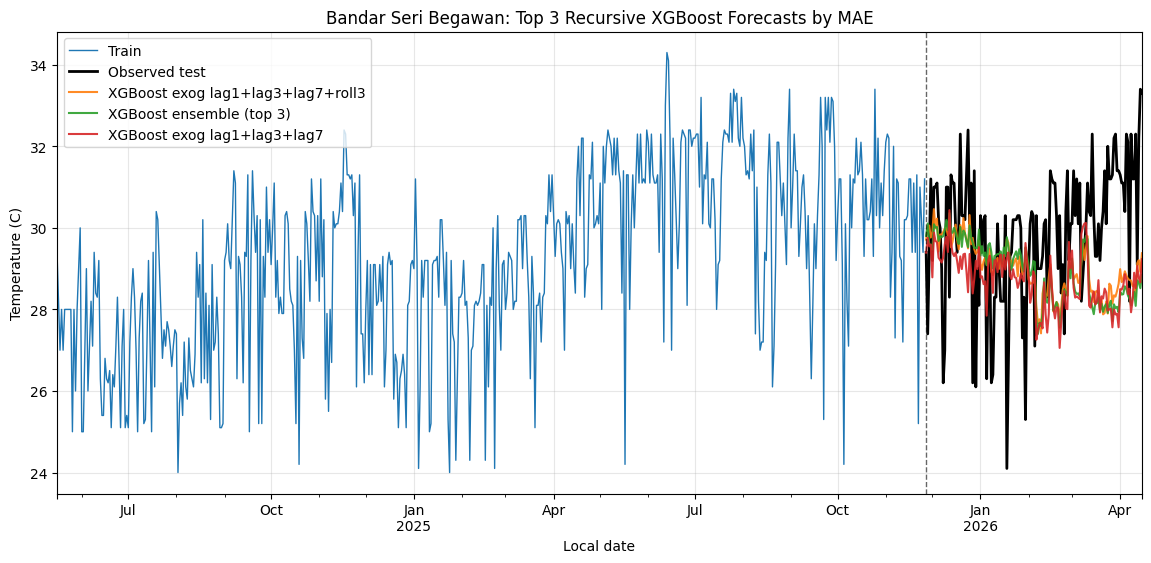

,model,model_type,mae,rmse,aic,bic,n_features
0,XGBoost exog lag1+lag3+lag7+roll3,Gradient boosted trees,1.680241,2.045387,NaN,NaN,31.0
1,XGBoost ensemble (top 3),Gradient boosted trees ensemble,1.775431,2.176961,NaN,NaN,NaN
2,XGBoost exog lag1+lag3+lag7,Gradient boosted trees,1.866478,2.210963,NaN,NaN,25.0


In [28]:
if xgboost_forecasts and not xgboost_results_df.empty:
    top_3_xgboost_models = xgboost_results_df.sort_values("mae").head(3)["model"].tolist()

    fig, ax = plt.subplots(figsize=(14, 6))

    bsb_train_repaired[TARGET_COL].plot(ax=ax, label="Train", linewidth=1)
    bsb_test[TARGET_COL].dropna().plot(ax=ax, label="Observed test", linewidth=2, color="black")

    for model_name in top_3_xgboost_models:
        xgboost_forecasts[model_name].plot(ax=ax, label=model_name, linewidth=1.5, alpha=0.9)

    ax.axvline(split_date, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(f"{SELECTED_CITY}: Top 3 Recursive XGBoost Forecasts by MAE")
    ax.set_xlabel("Local date")
    ax.set_ylabel("Temperature (C)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

    display(xgboost_results_df.loc[xgboost_results_df["model"].isin(top_3_xgboost_models)].sort_values("mae"))
else:
    print("Top-3 XGBoost plot is unavailable because XGBoost results are empty.")

## Final Model Comparison

Use MAE as the primary decision metric because it is directly interpretable as average absolute temperature error in Celsius. RMSE supplements the decision by showing whether a model has larger occasional misses. AIC and BIC are only comparable among the ARIMA candidates and should not be used to rank ARIMA against moving average or XGBoost models.

In [29]:
comparison_frames = [
    df
    for df in [moving_average_results_df, arima_results_df, xgboost_results_df]
    if not df.empty
]

if comparison_frames:
    model_comparison = (
        pd.concat(comparison_frames, ignore_index=True)
        .sort_values("mae")
        .reset_index(drop=True)
    )
    display(model_comparison)
else:
    print("No model results are available yet. Check whether statsmodels or xgboost is installed.")

,model,model_type,mae,rmse,aic,bic,n_features
0,"ARIMA(1, 1, 1)",ARIMA,1.205654,1.637954,2153.899295,2166.866990,NaN
1,"ARIMA(0, 1, 1)",ARIMA,1.218489,1.626706,2165.550161,2174.195291,NaN
2,7-day moving average,Recursive baseline,1.239592,1.619948,NaN,NaN,NaN
3,"ARIMA(1, 1, 0)",ARIMA,1.312714,1.772746,2254.613697,2263.262415,NaN
4,XGBoost exog lag1+lag3+lag7+roll3,Gradient boosted trees,1.680241,2.045387,NaN,NaN,31.0
5,XGBoost ensemble (top 3),Gradient boosted trees ensemble,1.775431,2.176961,NaN,NaN,NaN
6,XGBoost exog lag1+lag3+lag7,Gradient boosted trees,1.866478,2.210963,NaN,NaN,25.0
7,XGBoost selected top 10,Gradient boosted trees,1.870604,2.385653,NaN,NaN,10.0
8,XGBoost exog full,Gradient boosted trees,1.912093,2.287499,NaN,NaN,37.0
9,XGBoost ensemble (all variants),Gradient boosted trees ensemble,1.966241,2.331499,NaN,NaN,NaN


## Final 7-Day Forecast Zoom

This graph is a visual zoom into the first seven days of the test window. It does not replace the full holdout metrics above. It shows the moving-average baseline, all ARIMA candidates, and only the top three XGBoost variants by full-window MAE.

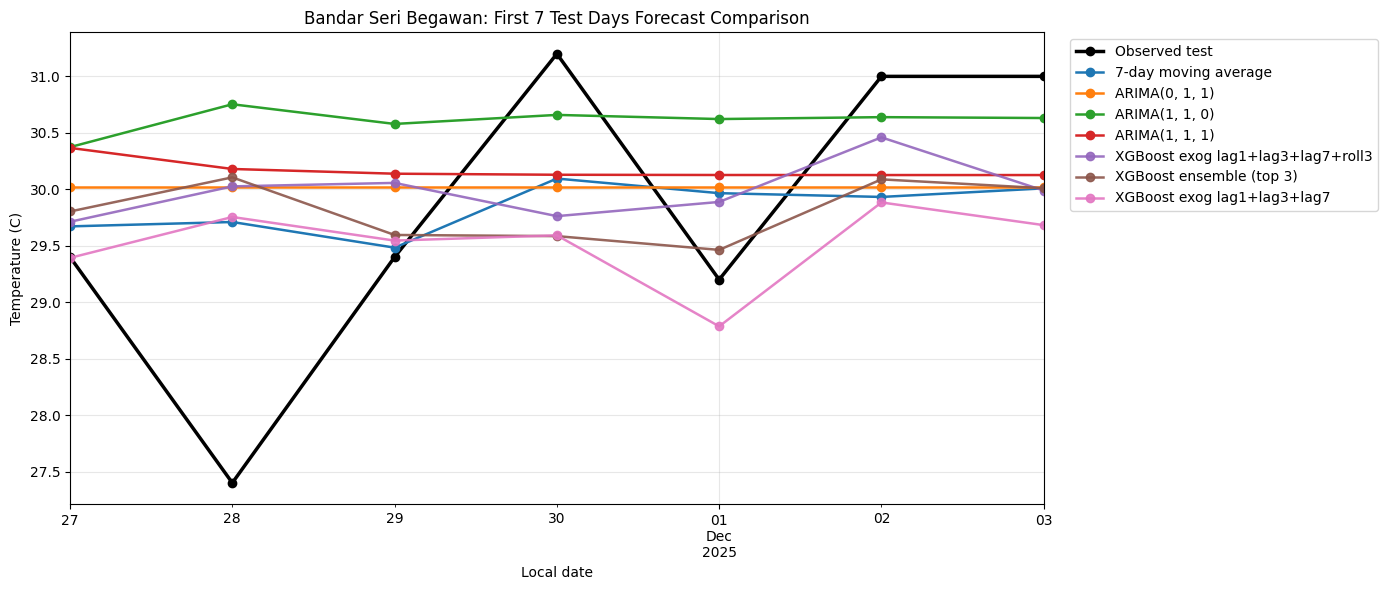

,model,model_type,mae,rmse,aic,bic,n_features
0,"ARIMA(1, 1, 1)",ARIMA,1.205654,1.637954,2153.899295,2166.866990,NaN
1,"ARIMA(0, 1, 1)",ARIMA,1.218489,1.626706,2165.550161,2174.195291,NaN
2,7-day moving average,Recursive baseline,1.239592,1.619948,NaN,NaN,NaN
3,"ARIMA(1, 1, 0)",ARIMA,1.312714,1.772746,2254.613697,2263.262415,NaN
4,XGBoost exog lag1+lag3+lag7+roll3,Gradient boosted trees,1.680241,2.045387,NaN,NaN,31.0
5,XGBoost ensemble (top 3),Gradient boosted trees ensemble,1.775431,2.176961,NaN,NaN,NaN
6,XGBoost exog lag1+lag3+lag7,Gradient boosted trees,1.866478,2.210963,NaN,NaN,25.0


In [30]:
ZOOM_DAYS = 7
zoom_index = bsb_test.index[:ZOOM_DAYS]

fig, ax = plt.subplots(figsize=(14, 6))

bsb_test[TARGET_COL].reindex(zoom_index).plot(
    ax=ax,
    label="Observed test",
    color="black",
    linewidth=2.5,
    marker="o",
)

moving_average_forecast.loc[zoom_index].plot(
    ax=ax,
    label=f"{MOVING_AVERAGE_WINDOW}-day moving average",
    linewidth=1.8,
    marker="o",
)

for model_name, forecast in arima_forecasts.items():
    forecast.loc[zoom_index].plot(ax=ax, label=model_name, linewidth=1.8, marker="o")

if xgboost_forecasts and not xgboost_results_df.empty:
    top_3_xgboost_models = xgboost_results_df.sort_values("mae").head(3)["model"].tolist()
    for model_name in top_3_xgboost_models:
        xgboost_forecasts[model_name].loc[zoom_index].plot(
            ax=ax,
            label=model_name,
            linewidth=1.8,
            marker="o",
            alpha=0.9,
        )

ax.set_title(f"{SELECTED_CITY}: First {ZOOM_DAYS} Test Days Forecast Comparison")
ax.set_xlabel("Local date")
ax.set_ylabel("Temperature (C)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if "model_comparison" in globals() and not model_comparison.empty:
    plotted_model_names = [f"{MOVING_AVERAGE_WINDOW}-day moving average"] + list(arima_forecasts.keys())
    if xgboost_forecasts and not xgboost_results_df.empty:
        plotted_model_names += top_3_xgboost_models

    display(
        model_comparison.loc[model_comparison["model"].isin(plotted_model_names)]
        .sort_values("mae")
        .reset_index(drop=True)
    )

## Model-Based Outlier Detection

Outliers are defined here from ARIMA(1,1,1) residuals rather than raw values. A day is unusual if the final selected model cannot explain it well. The outlier threshold is learned from training residuals only, then applied to both training and observed test residuals for inspection.

In [31]:
def summarize_residual_outliers(
    actual: pd.Series,
    predicted: pd.Series,
    split_name: str,
    residual_median: float,
    residual_mad: float,
    threshold: float,
) -> pd.DataFrame:
    """Create a residual table and flag model-based outliers.

    A robust MAD-based (median absolute deviation) score is preferred because weather residuals can be
    skewed and occasional large misses are exactly what we are trying to detect.
    """
    residuals = actual - predicted
    outlier_frame = pd.DataFrame(
        {
            "split": split_name,
            "actual": actual,
            "predicted": predicted,
            "residual": residuals,
            "absolute_residual": residuals.abs(),
        }
    )

    if residual_mad > 0:
        # The constant 0.6745 makes the MAD-based score comparable to a z-score under normality assumptions.
        outlier_frame["residual_score"] = 0.6745 * (residuals - residual_median) / residual_mad
        outlier_frame["is_outlier"] = outlier_frame["residual_score"].abs() > threshold
    else:
        # If MAD collapses to zero, fall back to a simple no-flag path instead
        # of inventing unstable thresholds from a nearly constant residual set.
        outlier_frame["residual_score"] = np.nan
        outlier_frame["is_outlier"] = False

    return outlier_frame


ARIMA_OUTLIER_MODEL = "ARIMA(1, 1, 1)"
training_actual = pd.Series(dtype="float64")
training_predicted = pd.Series(dtype="float64")
test_actual = bsb_test[TARGET_COL].dropna().copy()
test_predicted = pd.Series(dtype="float64")

if ARIMA_OUTLIER_MODEL in arima_forecasts:
    best_arima_model = ARIMA(
        arima_train_target,
        order=(1, 1, 1),
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()

    # In-sample predictions are used only to define the residual outlier rule
    # on training data. The test rule still comes from this training fit.
    training_predicted = best_arima_model.get_prediction(
        start=arima_train_target.index[1],
        end=arima_train_target.index[-1],
    ).predicted_mean
    training_actual = arima_train_target.loc[training_predicted.index]
    test_predicted = arima_forecasts[ARIMA_OUTLIER_MODEL].loc[test_actual.index]

    training_residuals = training_actual - training_predicted
    training_residual_median = float(training_residuals.median())
    training_residual_mad = float(np.median(np.abs(training_residuals - training_residual_median)))
    OUTLIER_SCORE_THRESHOLD = 3.5

    training_outlier_frame = summarize_residual_outliers(
        actual=training_actual,
        predicted=training_predicted,
        split_name="train",
        residual_median=training_residual_median,
        residual_mad=training_residual_mad,
        threshold=OUTLIER_SCORE_THRESHOLD,
    )
    test_outlier_frame = summarize_residual_outliers(
        actual=test_actual,
        predicted=test_predicted,
        split_name="test",
        residual_median=training_residual_median,
        residual_mad=training_residual_mad,
        threshold=OUTLIER_SCORE_THRESHOLD,
    )
    model_outlier_report = (
        pd.concat([training_outlier_frame, test_outlier_frame])
        .sort_values(["is_outlier", "absolute_residual"], ascending=[False, False])
    )

    print(f"Model used for outlier detection: {ARIMA_OUTLIER_MODEL}")
    print(f"Training residual median: {training_residual_median:.3f}")
    print(f"Training residual MAD: {training_residual_mad:.3f}")
    print(f"MAD-based outlier threshold: |score| > {OUTLIER_SCORE_THRESHOLD}")
    display(model_outlier_report.loc[model_outlier_report["is_outlier"]].head(20))
else:
    print("Run the ARIMA forecasting section before detecting model-based outliers.")


Model used for outlier detection: ARIMA(1, 1, 1)
Training residual median: 0.311
Training residual MAD: 0.930
MAD-based outlier threshold: |score| > 3.5


,split,actual,predicted,residual,absolute_residual,residual_score,is_outlier
local_date,,,,,,,
2025-05-17,train,24.20,31.025338,-6.825338,6.825338,-5.174921,True
2025-10-05,train,24.20,30.417900,-6.217900,6.217900,-4.734442,True
2026-01-18,test,24.10,30.125963,-6.025963,6.025963,-4.595261,True
2025-09-22,train,25.30,30.773397,-5.473397,5.473397,-4.194571,True
2025-11-22,train,25.20,30.585087,-5.385087,5.385087,-4.130534,True
2026-01-30,test,25.30,30.125963,-4.825963,4.825963,-3.725090,True
2025-06-16,train,27.00,31.670108,-4.670108,4.670108,-3.612072,True
2025-08-09,train,27.40,32.002893,-4.602893,4.602893,-3.563332,True
2025-08-20,train,26.10,30.660486,-4.560486,4.560486,-3.532581,True


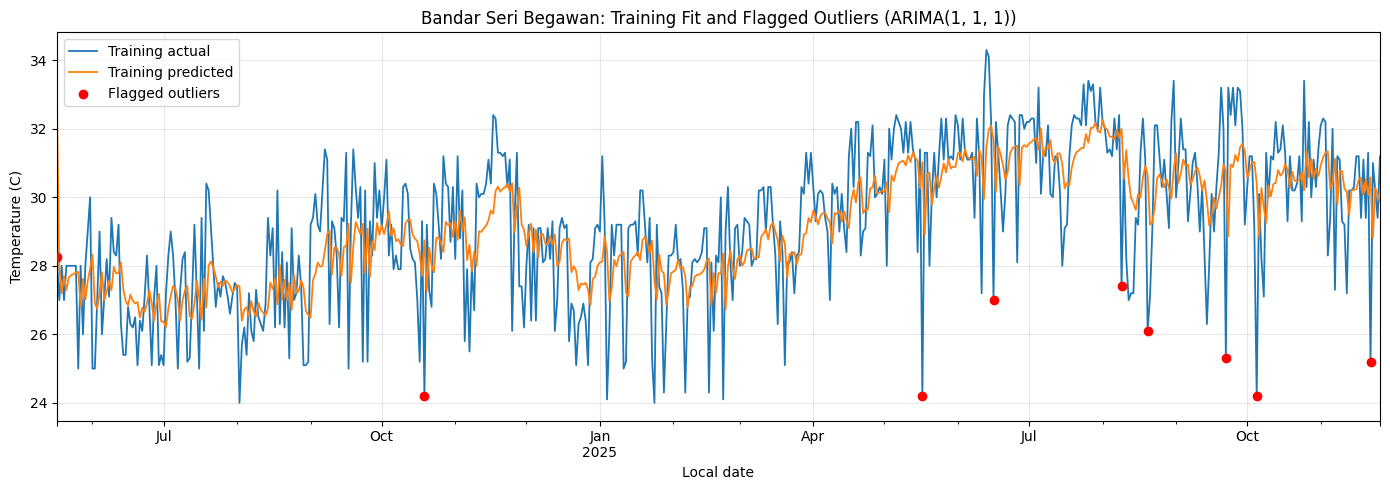

In [32]:
if "model_outlier_report" in globals() and not model_outlier_report.empty:
    fig, ax = plt.subplots(figsize=(14, 5))

    train_plot_frame = pd.DataFrame(
        {
            "actual": training_actual,
            "predicted": training_predicted,
        }
    )
    train_outliers = training_outlier_frame.loc[training_outlier_frame["is_outlier"]]

    train_plot_frame["actual"].plot(ax=ax, label="Training actual", linewidth=1.3)
    train_plot_frame["predicted"].plot(ax=ax, label="Training predicted", linewidth=1.3)
    if not train_outliers.empty:
        ax.scatter(
            train_outliers.index,
            train_outliers["actual"],
            color="red",
            label="Flagged outliers",
            zorder=3,
        )
    ax.set_title(f"{SELECTED_CITY}: Training Fit and Flagged Outliers ({ARIMA_OUTLIER_MODEL})")
    ax.set_xlabel("Local date")
    ax.set_ylabel("Temperature (C)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Run model-based outlier detection before plotting outliers.")


## Outlier Treatment

The flagged outliers are retained rather than altered or removed. There are relatively few of them, and the final model is ARIMA(1,1,1), so replacing these days would risk distorting genuine variation in the daily temperature series. For this project, the outliers are reported transparently and the model is carried forward unchanged.

## Results Interpretation

In general, the ARIMA family models outperformed all types of XGBoost models on the holdout set. In particular, `ARIMA(1,1,1)` achieved the lowest MAE and nearly the lowest RMSE, though the margin over the 7-day moving average model was modest. 

Overall, this suggests that Bandar Seri Begawan's daily temperature series is largely driven by short-memory, linear temporal processes. As we can see in the results, there is limited evidence that additional exogeneous or nonlinear feature-based modelling significantly improves forecast accuracy.